In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.pipeline import Pipeline
import warnings, joblib, json, os, pathlib
warnings.filterwarnings('ignore')
print('All imports successful')

All imports successful


In [2]:
CSV_PATH = 'sec_final_training_data.csv'  

data = pd.read_csv(CSV_PATH)
print(f'Loaded {len(data)} rows, {len(data.columns)} columns')
data.head(3)

Loaded 320 rows, 27 columns


,team,name,position,class,height_in,weight_lb,games_played,follower_count,instagram_user,engagement_rate,...,season_rush_yards,career_rush_yards,season_scoring_td,career_scoring_td,season_def_tackles,career_def_tackles,season_def_sacks,career_def_sacks,performance_data_status,nil_value
0,Alabama Crimson Tide,Ryan Williams,WR,SO,73.0,178,27,"755,457",NaN,0.2459,...,21,69,4,14,0,0,0.0,0.0,1,1600000.0
1,Alabama Crimson Tide,Keelon Russell,QB,FR,75.0,194,2,105414,NaN,0.1075,...,17,17,0,0,0,0,0.0,0.0,1,1300000.0
2,Alabama Crimson Tide,Yhonzae Pierre,LB,SO,75.0,248,26,15848,NaN,0.6129,...,0,0,0,0,52,58,8.0,8.0,1,976000.0


In [3]:
df = data.copy()
print('Shape:', df.shape)
print('\nMissing values:')
print(df.isnull().sum())
print('\nDuplicates:', df.duplicated().sum())
print('\nUnique players:', df['name'].nunique())

Shape: (320, 27)

Missing values:
team                         0
name                         0
position                     0
class                        0
height_in                    0
weight_lb                    0
games_played                 0
follower_count               1
instagram_user              93
engagement_rate            110
team_FPI                     0
team_RK                      0
program_tier                 0
season_pass_yards            0
career_pass_yards            0
season_rec_yards             0
career_rec_yards             0
season_rush_yards            0
career_rush_yards            0
season_scoring_td            0
career_scoring_td            0
season_def_tackles           0
career_def_tackles           0
season_def_sacks             0
career_def_sacks             1
performance_data_status      0
nil_value                   99
dtype: int64

Duplicates: 0

Unique players: 320


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
team,320,16,Florida Gators,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,320,320,Ryan Williams,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
position,320,20,WR,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,320,4,FR,118,NaN,NaN,NaN,NaN,NaN,NaN,NaN
height_in,320.0,NaN,NaN,NaN,73.94375,2.863667,58.0,72.0,74.0,76.0,80.0
weight_lb,320.0,NaN,NaN,NaN,224.403125,45.06453,155.0,190.0,213.0,248.5,360.0
games_played,320.0,NaN,NaN,NaN,21.171875,15.828187,0.0,8.0,19.5,32.0,61.0
follower_count,319,317,"3,354",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
instagram_user,227,227,byronlouis_,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engagement_rate,210.0,NaN,NaN,NaN,0.31035,0.301219,0.0,0.1382,0.2354,0.3643,2.0142


In [5]:
df = df.drop(columns=['instagram_user', 'engagement_rate'], errors='ignore')

df['follower_count'] = (
    df['follower_count'].astype(str)
    .str.replace(',', '', regex=False).str.strip()
)
df['follower_count'] = pd.to_numeric(df['follower_count'], errors='coerce')

pos_map = {
    'QB':   'QB',
    'WR':   'SKILL', 'TE': 'SKILL', 'RB': 'SKILL', 'BCK': 'SKILL',
    'OL':   'OL',    'OT': 'OL',    'IOL': 'OL',   'LS':  'OL',
    'DB':   'DEF_BACK', 'CB': 'DEF_BACK', 'S': 'DEF_BACK',
    'LB':   'LB',    'ILB': 'LB',   'OLB': 'LB',
    'DL':   'DL',    'DT':  'DL',   'DE':  'DL',
    'EDGE': 'DL',    'EDG': 'DL',
}
df['pos_group'] = df['position'].map(pos_map)
unmapped = df[df['pos_group'].isna()]['position'].unique()
if len(unmapped): print('WARNING - unmapped positions:', unmapped)

class_map = {'FR': 1, 'SO': 2, 'JR': 3, 'SR': 4, 'GR': 5}
df['class_num'] = df['class'].map(class_map)

df_labeled   = df[df['nil_value'].notna()].copy().reset_index(drop=True)
df_unlabeled = df[df['nil_value'].isna()].copy().reset_index(drop=True)

print(f'Labeled (has NIL):   {len(df_labeled)} players')
print(f'Unlabeled (no NIL):  {len(df_unlabeled)} players')
print('\nPosition group distribution (labeled):')
print(df_labeled['pos_group'].value_counts())

Labeled (has NIL):   221 players
Unlabeled (no NIL):  99 players

Position group distribution (labeled):
pos_group
SKILL       55
DEF_BACK    49
DL          36
OL          31
LB          26
QB          24
Name: count, dtype: int64


In [6]:
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2, sharex=True,
        gridspec_kw={'height_ratios': (0.25, 0.75)}, figsize=figsize,
    )
    sns.boxplot(data=data, x=feature, ax=ax_box2, showmeans=True, color='violet')
    if bins:
        sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins)
    else:
        sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2)
    ax_hist2.axvline(data[feature].mean(),   color='green', linestyle='--', label=f"Mean: {data[feature].mean():,.1f}")
    ax_hist2.axvline(data[feature].median(), color='black', linestyle='-',  label=f"Median: {data[feature].median():,.1f}")
    ax_hist2.legend()
    plt.suptitle(feature, fontsize=13)
    plt.tight_layout()
    plt.show()

def labeled_barplot(data, feature, perc=False, n=None):
    total = len(data[feature])
    count = data[feature].nunique()
    plt.figure(figsize=(min(count + 2, 20), 5))
    plt.xticks(rotation=90, fontsize=12)
    ax = sns.countplot(
        data=data, x=feature, palette='Paired',
        order=data[feature].value_counts().index[:n].sort_values(),
    )
    for p in ax.patches:
        label = '{:.1f}%'.format(100 * p.get_height() / total) if perc else p.get_height()
        ax.annotate(label, (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='center', size=11, xytext=(0, 5), textcoords='offset points')
    plt.tight_layout()
    plt.show()

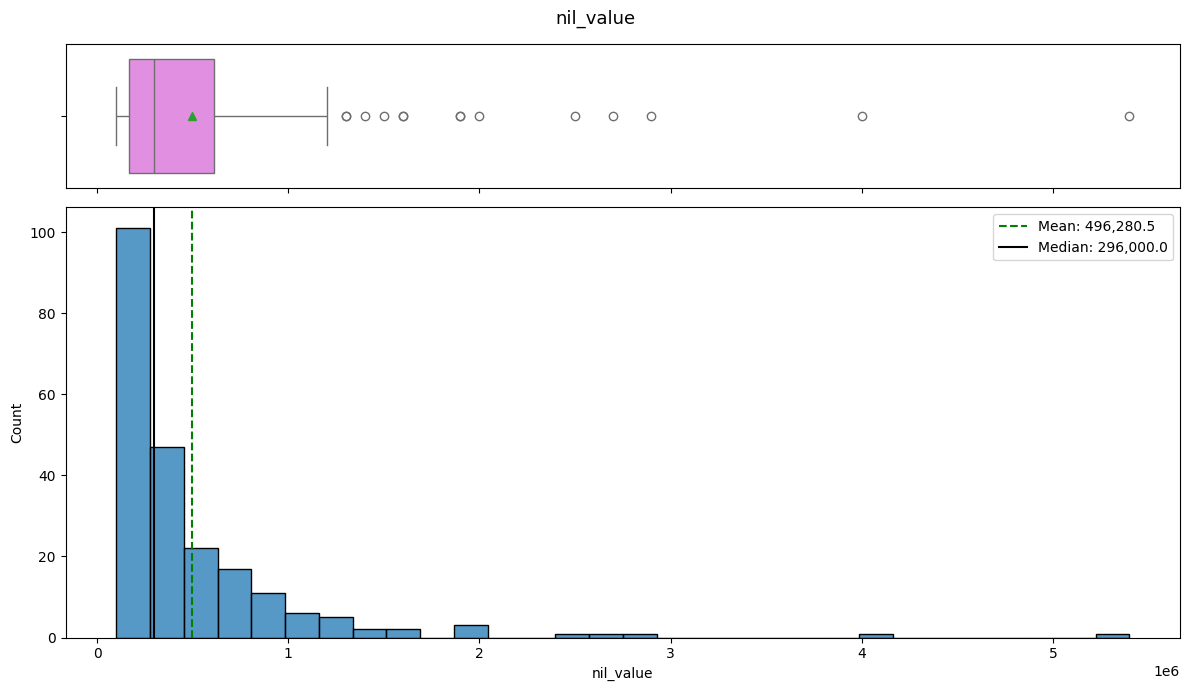

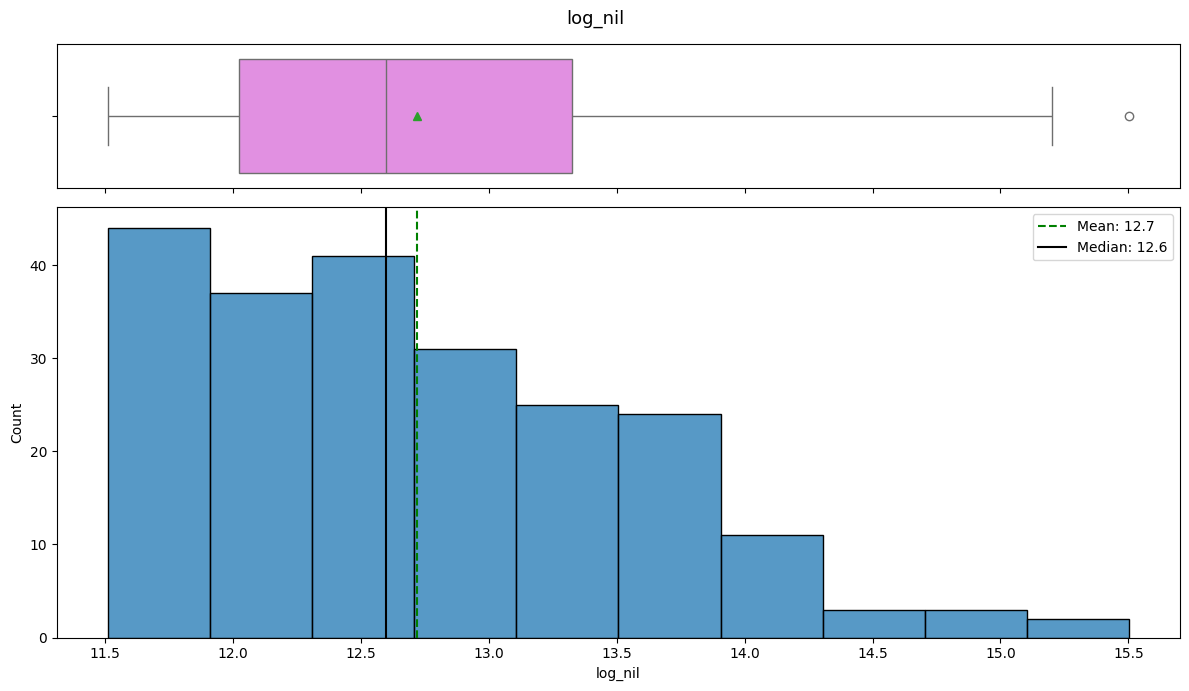

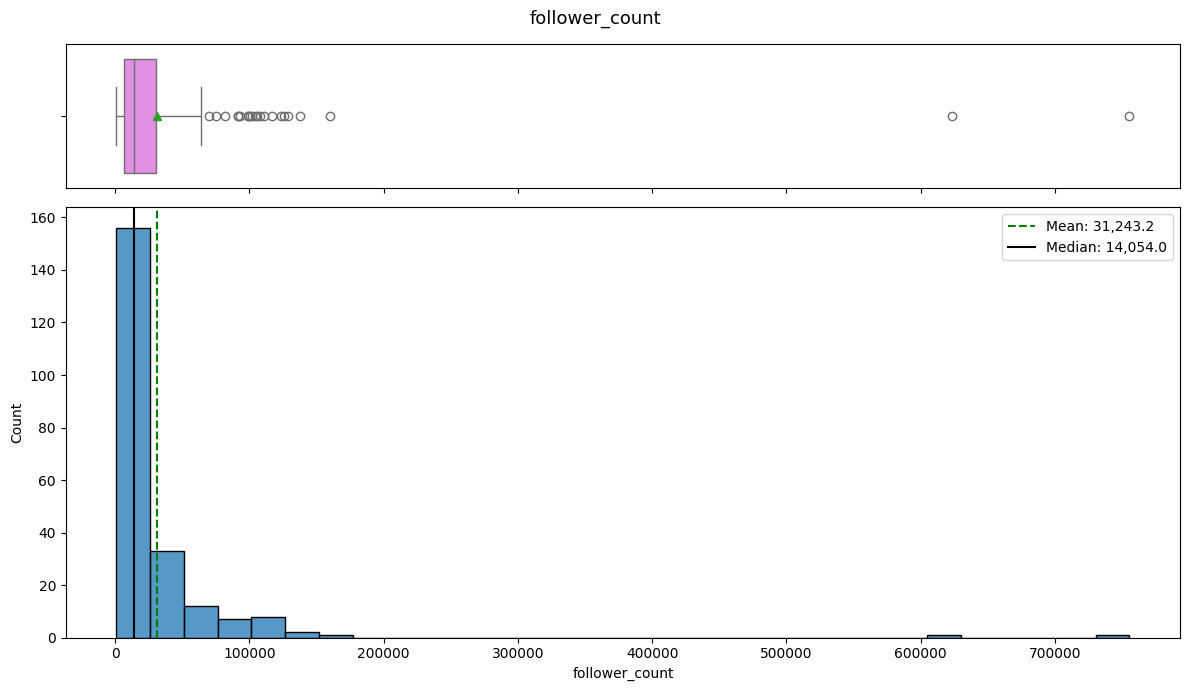

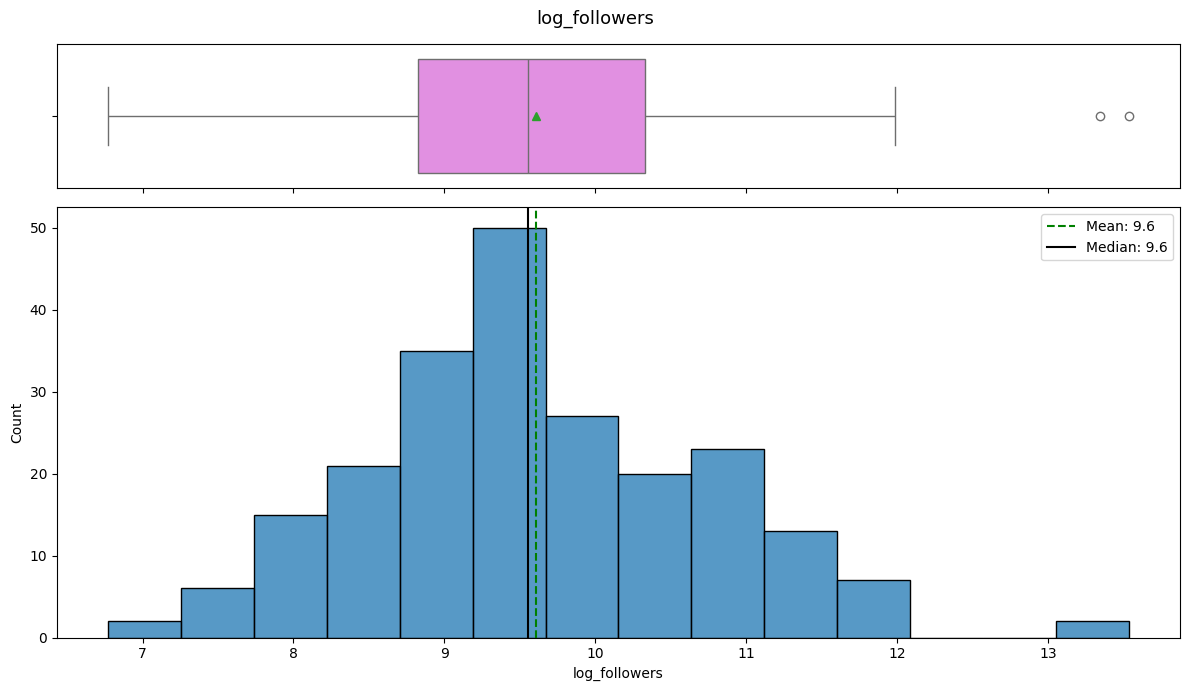

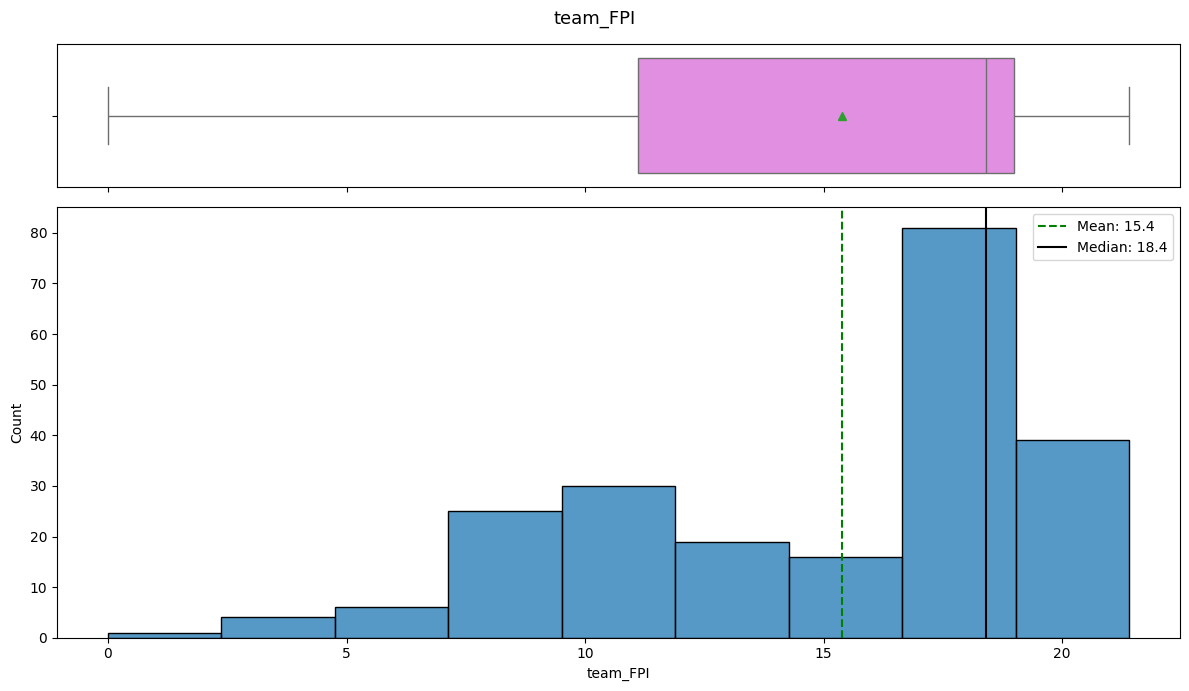

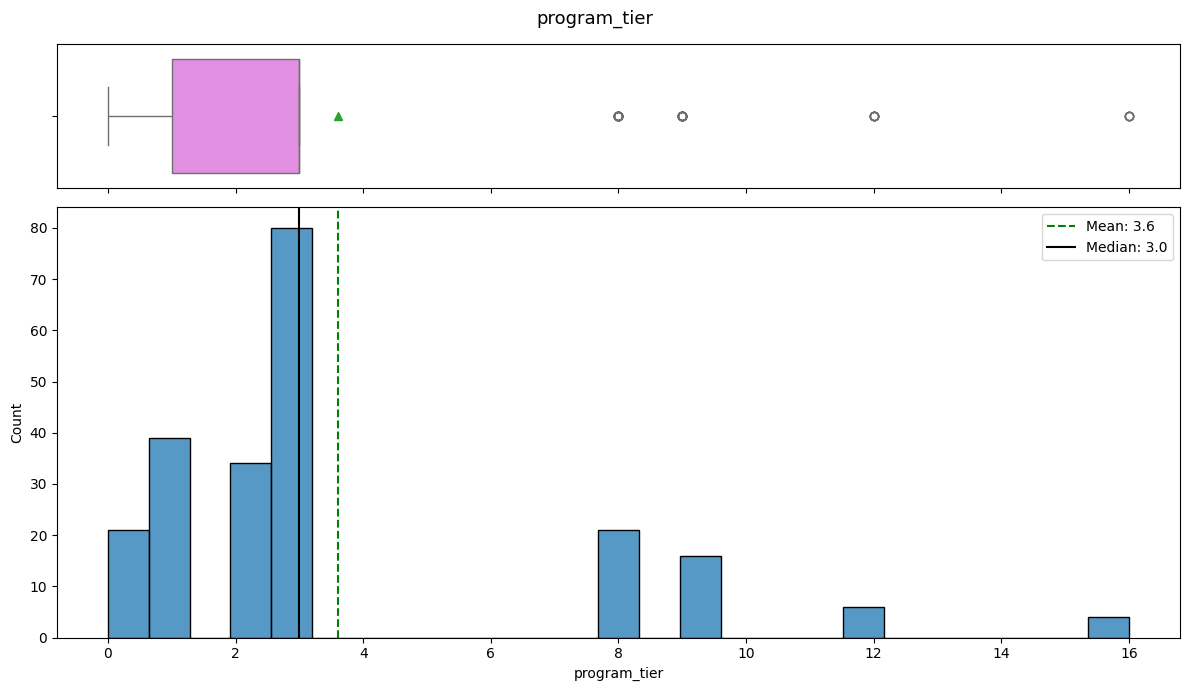

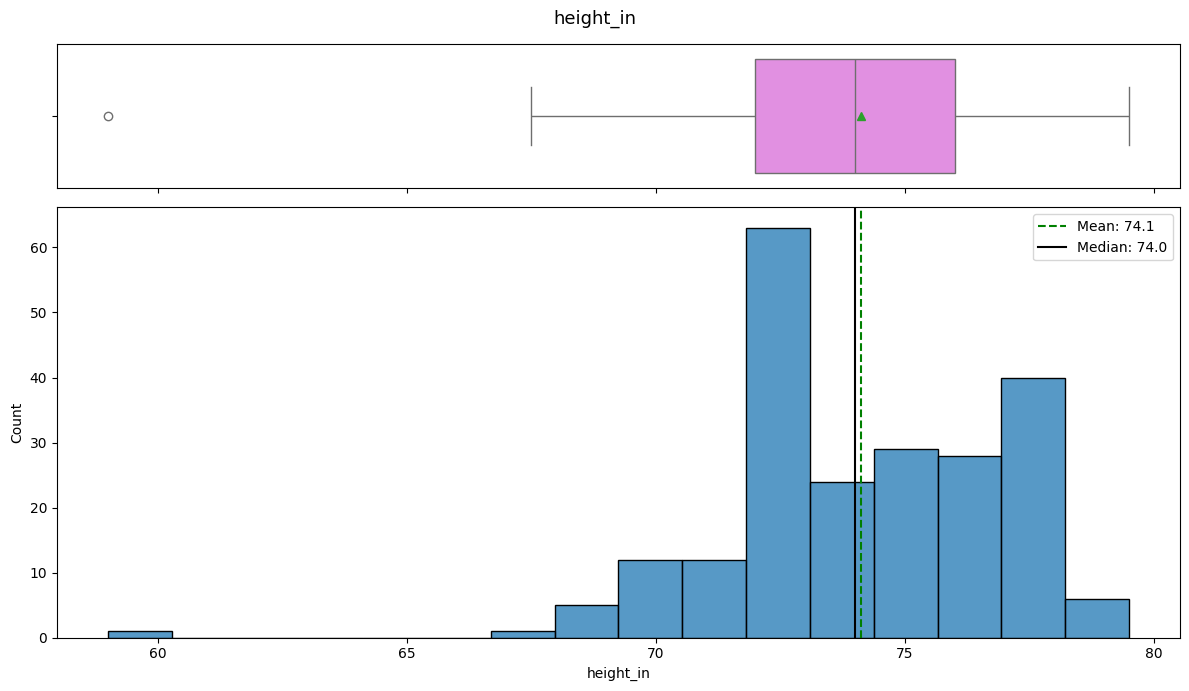

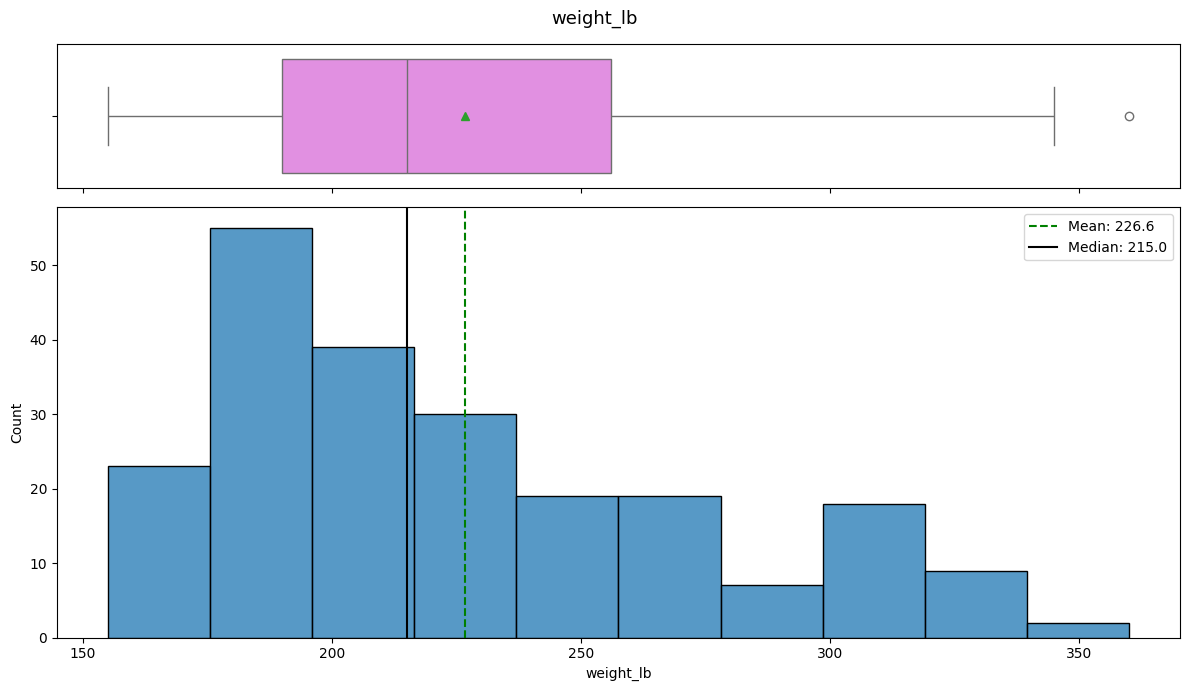

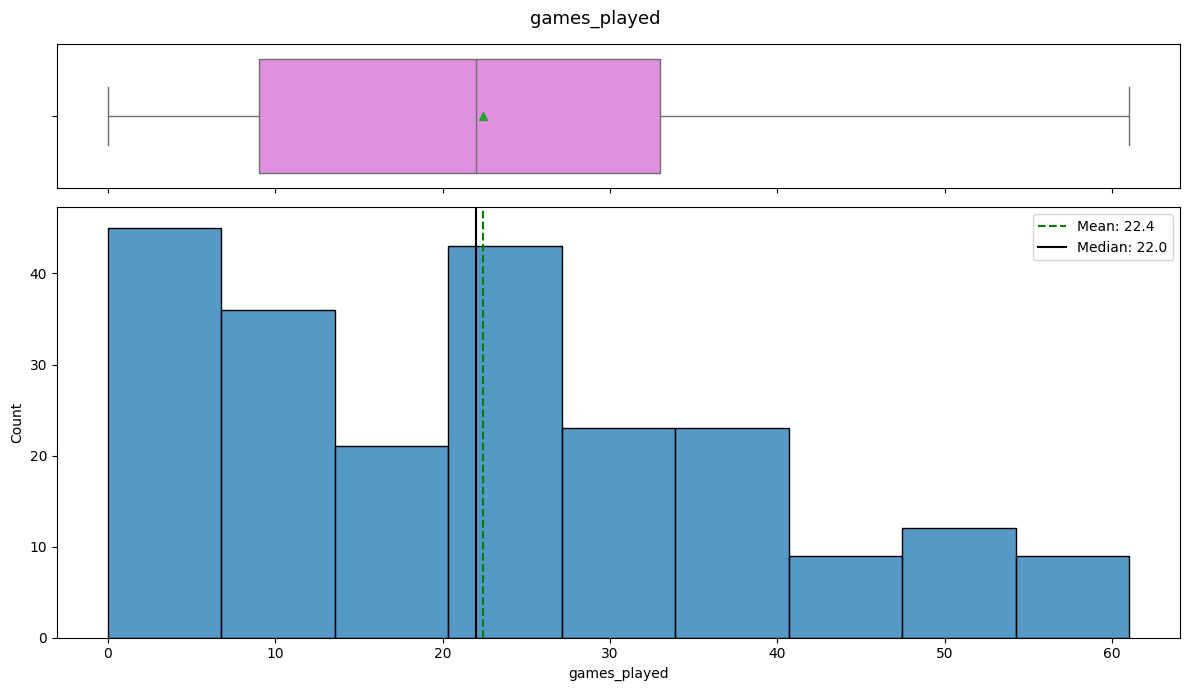

In [7]:
df_labeled['log_nil']       = np.log(df_labeled['nil_value'])
df_labeled['log_followers'] = np.log1p(df_labeled['follower_count'].fillna(0))

for col in ['nil_value', 'log_nil', 'follower_count', 'log_followers',
            'team_FPI', 'program_tier', 'height_in', 'weight_lb', 'games_played']:
    histogram_boxplot(df_labeled, col)

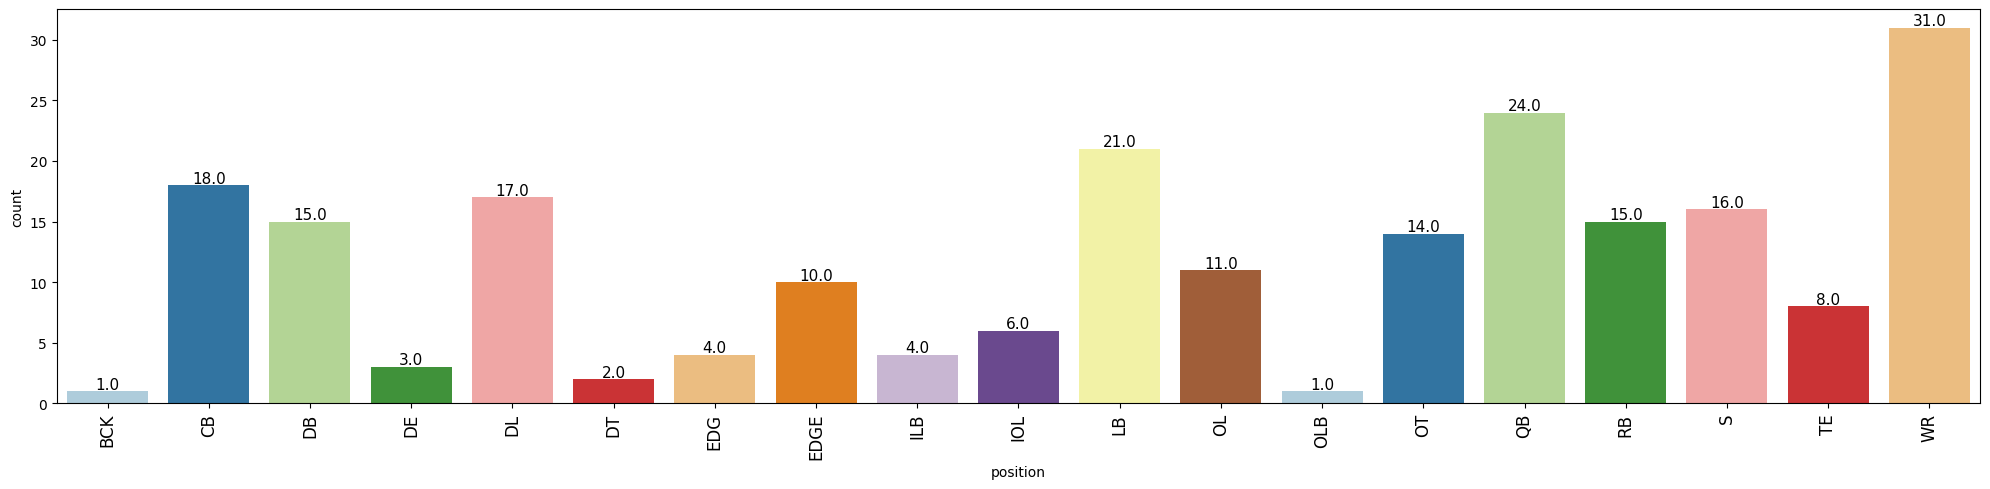

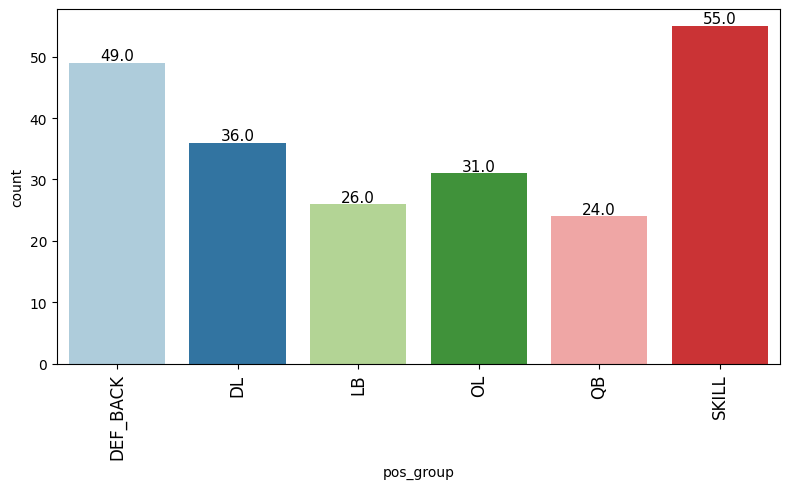

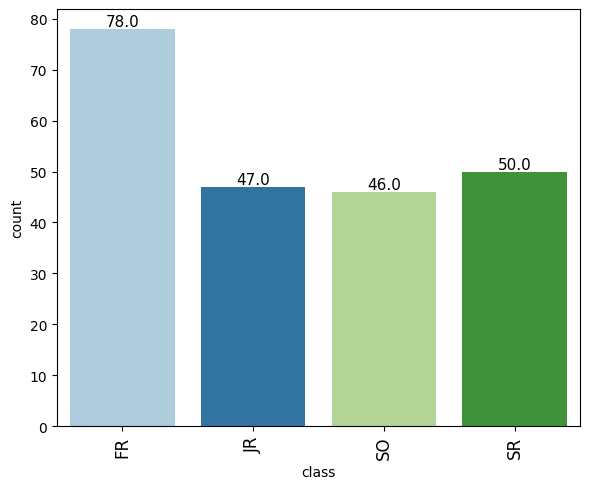

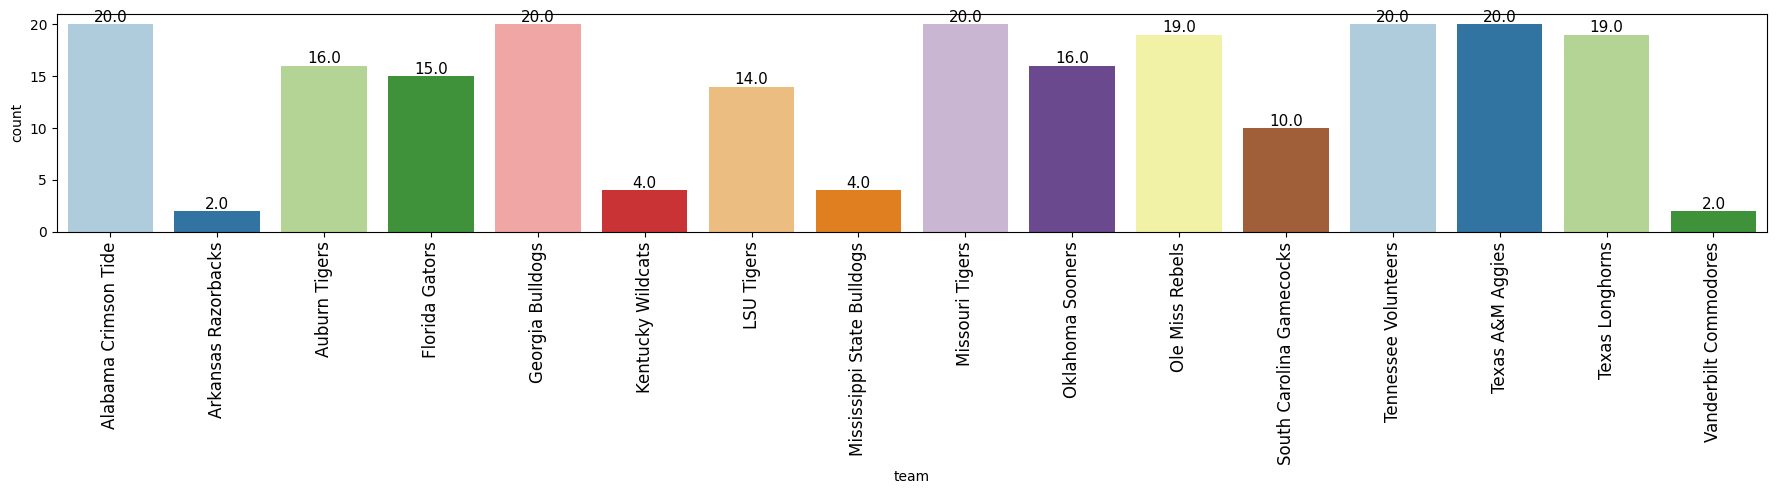

In [8]:
labeled_barplot(df_labeled, 'position')
labeled_barplot(df_labeled, 'pos_group')
labeled_barplot(df_labeled, 'class')
labeled_barplot(df_labeled, 'team')

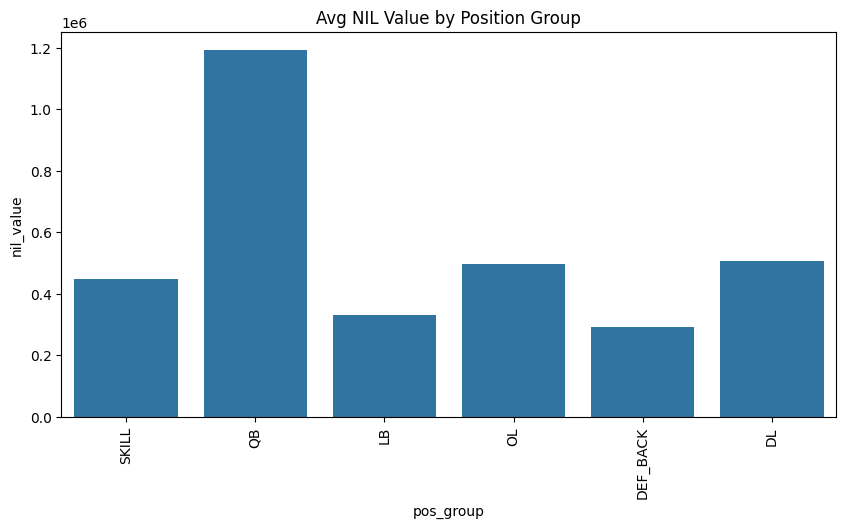

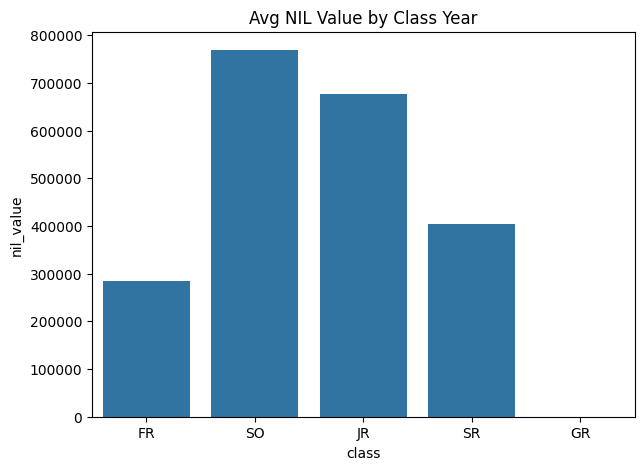

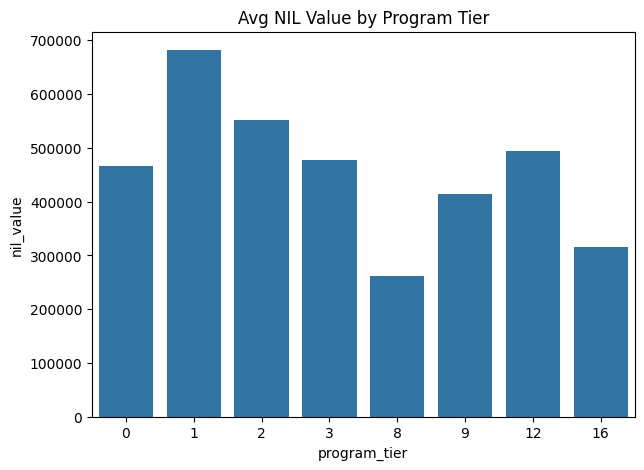

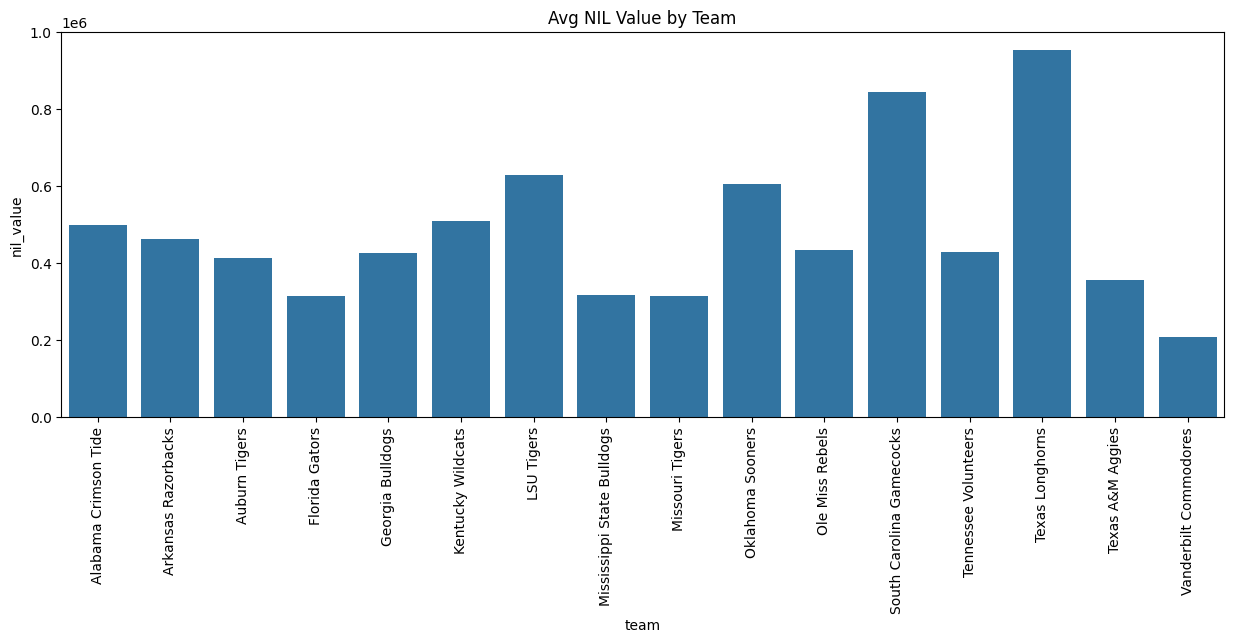

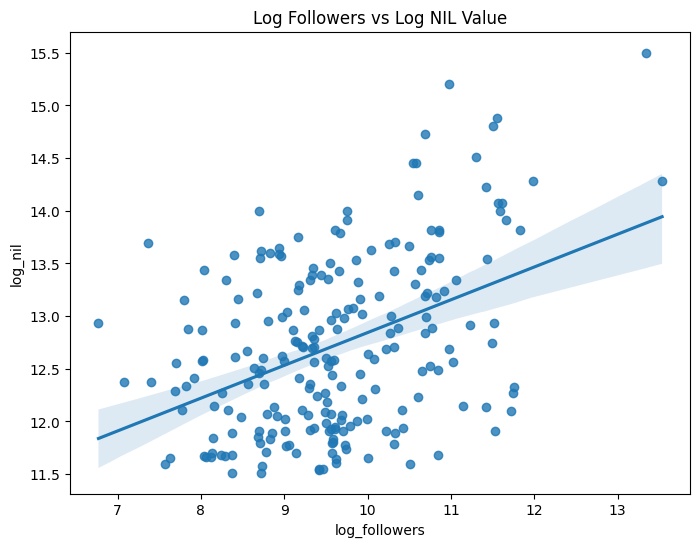

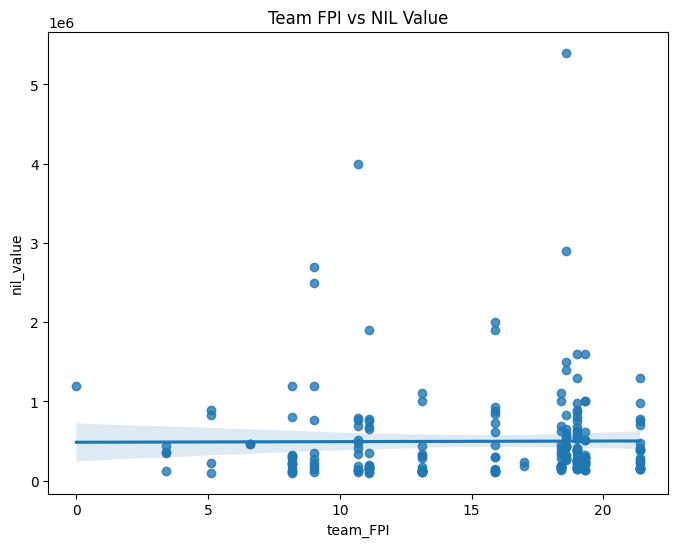

In [9]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df_labeled, x='pos_group', y='nil_value', errorbar=('ci', False))
plt.xticks(rotation=90)
plt.title('Avg NIL Value by Position Group')
plt.show()

plt.figure(figsize=(7, 5))
sns.barplot(data=df_labeled, x='class', y='nil_value', order=['FR','SO','JR','SR','GR'], errorbar=('ci', False))
plt.title('Avg NIL Value by Class Year')
plt.show()

plt.figure(figsize=(7, 5))
sns.barplot(data=df_labeled, x='program_tier', y='nil_value', errorbar=('ci', False))
plt.title('Avg NIL Value by Program Tier')
plt.show()

plt.figure(figsize=(15, 5))
sns.barplot(data=df_labeled, x='team', y='nil_value', errorbar=('ci', False))
plt.xticks(rotation=90)
plt.title('Avg NIL Value by Team')
plt.show()

plt.figure(figsize=(8, 6))
sns.regplot(x='log_followers', y='log_nil', data=df_labeled)
plt.title('Log Followers vs Log NIL Value')
plt.show()

plt.figure(figsize=(8, 6))
sns.regplot(x='team_FPI', y='nil_value', data=df_labeled)
plt.title('Team FPI vs NIL Value')
plt.show()

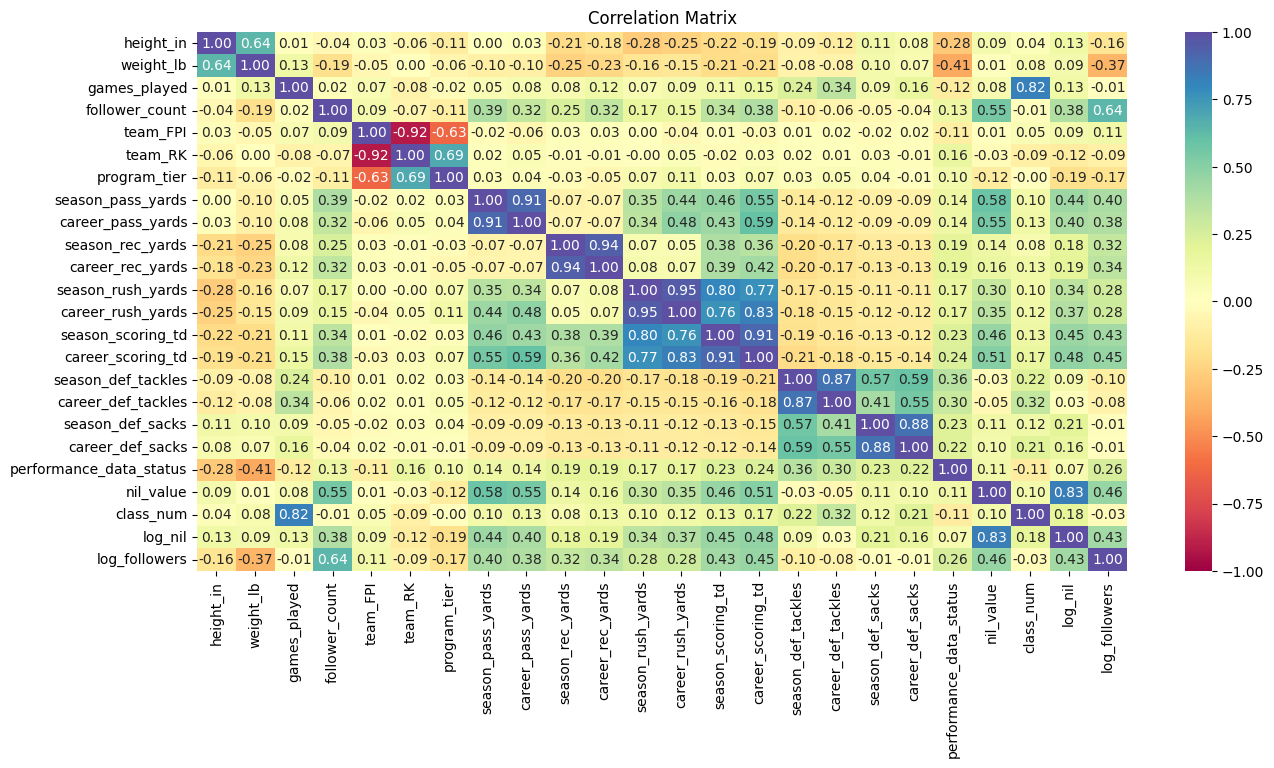

In [10]:
cols_list = df_labeled.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(15, 7))
sns.heatmap(
    df_labeled[cols_list].corr(numeric_only=True),
    annot=True, vmin=-1, vmax=1, fmt='.2f', cmap='Spectral'
)
plt.title('Correlation Matrix')
plt.show()

ANOVA: does position group significantly explain NIL variance?
                  sum_sq     df         F    PR(>F)
C(pos_group)   20.957935    5.0  7.001811  0.000004
Residual      128.708301  215.0       NaN       NaN


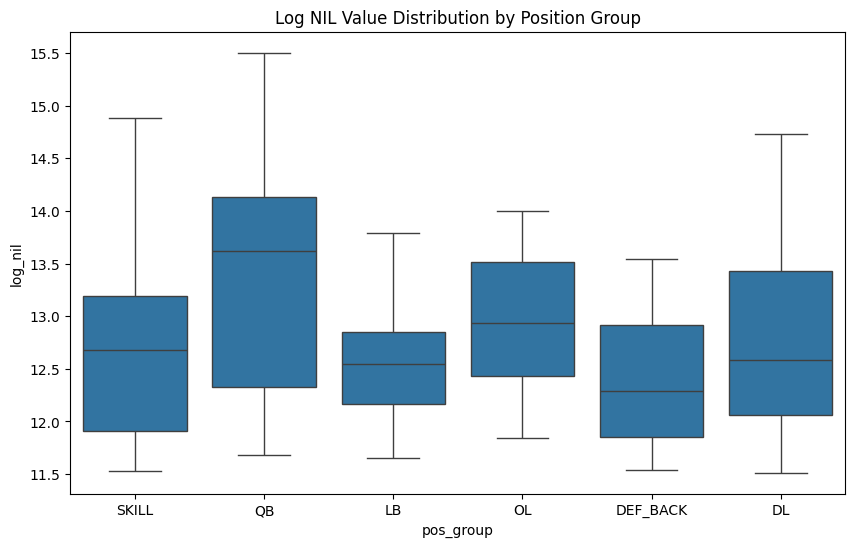

In [11]:
model_anova = ols('log_nil ~ C(pos_group)', data=df_labeled).fit()
anova_table = sm.stats.anova_lm(model_anova, typ=2)
print('ANOVA: does position group significantly explain NIL variance?')
print(anova_table)

plt.figure(figsize=(10, 6))
sns.boxplot(x='pos_group', y='log_nil', data=df_labeled)
plt.title('Log NIL Value Distribution by Position Group')
plt.show()

## 5. Position-Specific Performance Analysis

Each position group uses different stats as performance signals.
We compute a weighted performance score per position, normalize it within group,
then verify it correlates with NIL value before using it in the model.

Performance score correlation with log NIL value by position group:
  DEF_BACK     r=+0.554  ███████████  (n=49)
  DL           r=+0.547  ██████████  (n=36)
  LB           r=+0.192  ███  (n=26)
  OL           r=N/A   (no individual stats)  (n=31)
  QB           r=+0.688  █████████████  (n=24)
  SKILL        r=+0.743  ██████████████  (n=55)


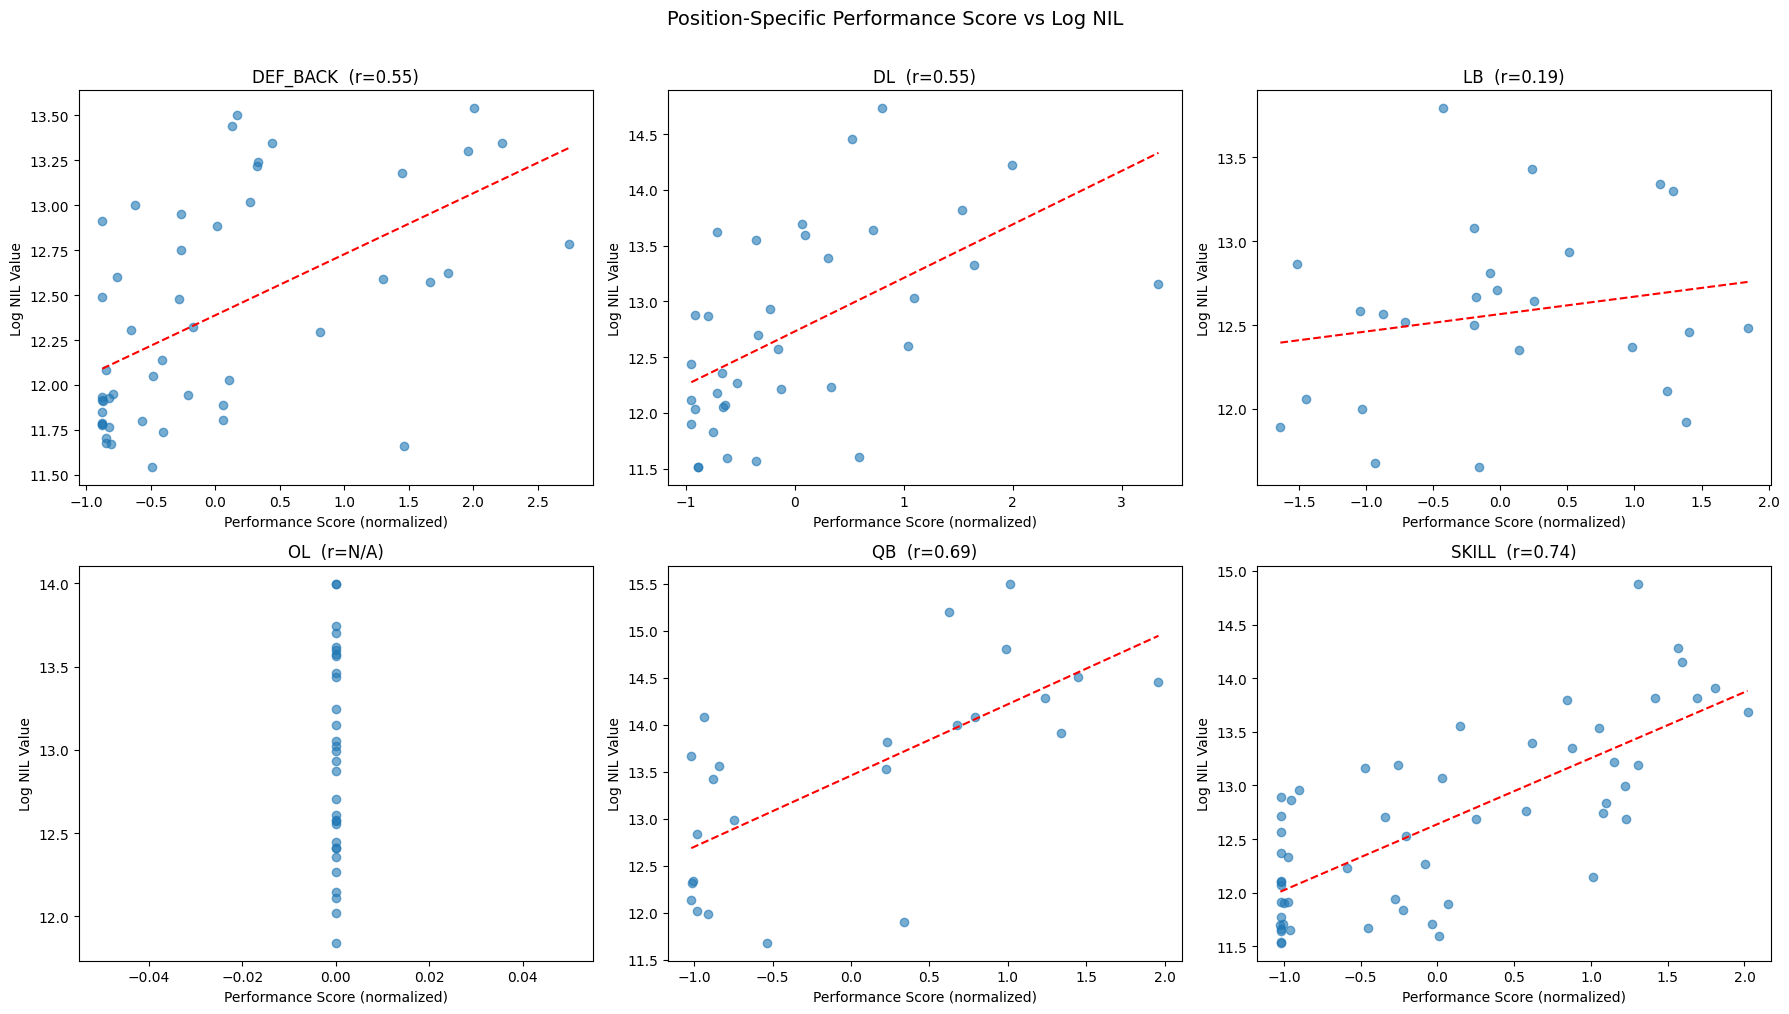

In [12]:
PERF_WEIGHTS = {
    'QB': {
        'season_pass_yards':  0.30, 'career_pass_yards':  0.20,
        'season_scoring_td':  0.25, 'career_scoring_td':  0.10,
        'season_rush_yards':  0.10, 'career_rush_yards':  0.05,
    },
    'SKILL': {
        'season_rec_yards':   0.30, 'career_rec_yards':   0.20,
        'season_rush_yards':  0.15, 'career_rush_yards':  0.10,
        'season_scoring_td':  0.15, 'career_scoring_td':  0.10,
    },
    'DEF_BACK': {
        'season_def_tackles': 0.35, 'career_def_tackles': 0.30,
        'season_def_sacks':   0.20, 'career_def_sacks':   0.15,
    },
    'LB': {
        'season_def_tackles': 0.40, 'career_def_tackles': 0.30,
        'season_def_sacks':   0.18, 'career_def_sacks':   0.12,
    },
    'DL': {
        'season_def_sacks':   0.40, 'career_def_sacks':   0.30,
        'season_def_tackles': 0.18, 'career_def_tackles': 0.12,
    },
    'OL': {},
}

PHYSICAL_WEIGHTS = {
    'QB':       {'height': 0.3, 'weight': 0.3},
    'SKILL':    {'height': 0.4, 'weight': 0.2},
    'DEF_BACK': {'height': 0.2, 'weight': 0.5},
    'LB':       {'height': 0.3, 'weight': 0.4},
    'DL':       {'height': 0.3, 'weight': 0.5},
    'OL':       {'height': 0.4, 'weight': 0.5},
}

def compute_perf_score(row):
    pg = row['pos_group']
    weights = PERF_WEIGHTS.get(pg, {})
    if not weights:
        return 0.0
    return sum(w * (row[col] if pd.notna(row[col]) else 0)
               for col, w in weights.items())

for data_df in [df_labeled, df_unlabeled]:
    data_df['perf_score_raw'] = data_df.apply(compute_perf_score, axis=1)

perf_stats = df_labeled.groupby('pos_group')['perf_score_raw'].agg(['mean','std'])

def normalize_perf(row):
    pg = row['pos_group']
    if pg not in perf_stats.index or perf_stats.loc[pg, 'std'] == 0:
        return 0.0
    return (row['perf_score_raw'] - perf_stats.loc[pg, 'mean']) / perf_stats.loc[pg, 'std']

for data_df in [df_labeled, df_unlabeled]:
    data_df['perf_score'] = data_df.apply(normalize_perf, axis=1)

print('Performance score correlation with log NIL value by position group:')
for pg, grp in df_labeled.groupby('pos_group'):
    corr = grp['perf_score'].corr(grp['log_nil'])
    if pd.isna(corr):
        print(f'  {pg:<12} r=N/A   (no individual stats)  (n={len(grp)})')
        continue
    bar = '\u2588' * int(abs(corr) * 20)
    print(f'  {pg:<12} r={corr:+.3f}  {bar}  (n={len(grp)})')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, (pg, grp) in enumerate(df_labeled.groupby('pos_group')):
    if i >= 6: break
    axes[i].scatter(grp['perf_score'], grp['log_nil'], alpha=0.6)
    if grp['perf_score'].std() > 0:
        m, b = np.polyfit(grp['perf_score'], grp['log_nil'], 1)
        xs = np.linspace(grp['perf_score'].min(), grp['perf_score'].max(), 50)
        axes[i].plot(xs, m*xs+b, 'r--', linewidth=1.5)
    corr_label = f'{grp["perf_score"].corr(grp["log_nil"]):.2f}' if grp['perf_score'].std() > 0 else 'N/A'
    axes[i].set_title(f'{pg}  (r={corr_label})')
    axes[i].set_xlabel('Performance Score (normalized)')
    axes[i].set_ylabel('Log NIL Value')
plt.suptitle('Position-Specific Performance Score vs Log NIL', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Height & Weight by Position Group (mean +/- std):
          height_in      weight_lb      
               mean  std      mean   std
pos_group                               
DEF_BACK       72.7  1.6     186.9  14.7
DL             76.0  1.5     269.8  29.7
LB             73.5  1.2     223.1  16.8
OL             77.2  1.3     304.6  27.6
QB             74.7  1.7     207.8  16.8
SKILL          72.5  3.3     199.7  26.2

Physical score correlation with log NIL by position group:
  DEF_BACK     r=+0.298  █████
  DL           r=-0.094  █
  LB           r=-0.250  ████
  OL           r=-0.066  █
  QB           r=-0.036  
  SKILL        r=-0.044  


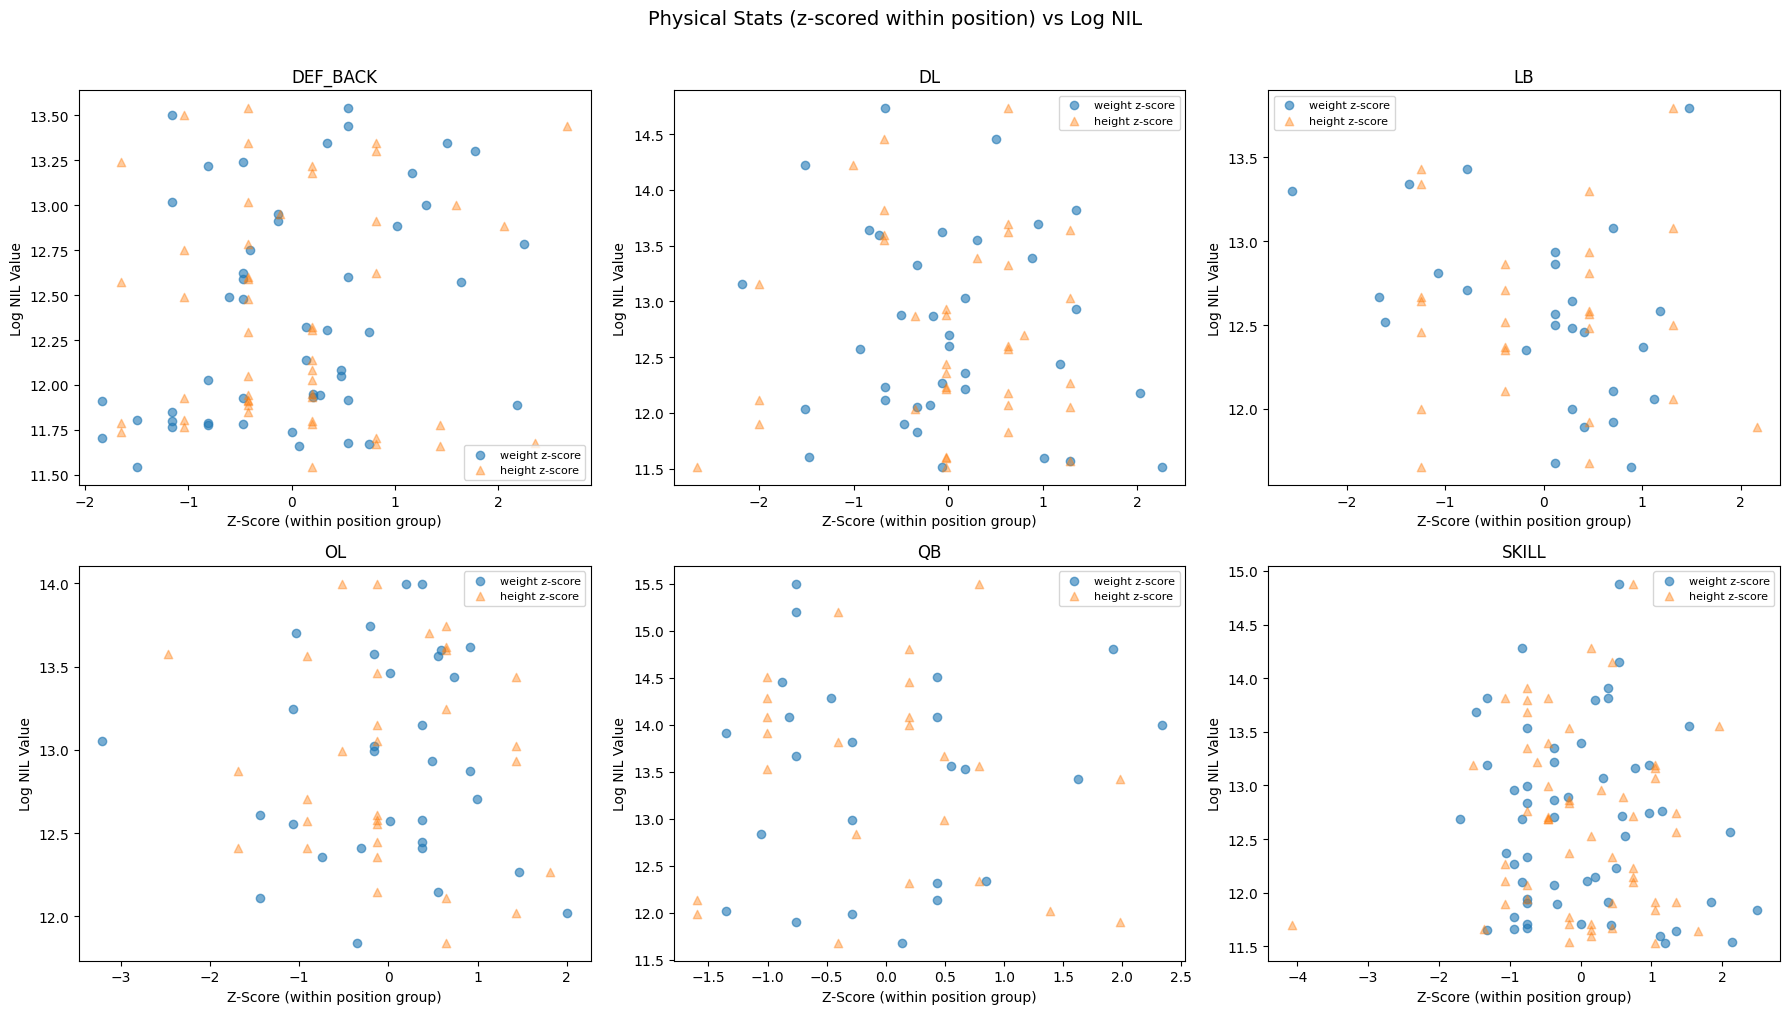

In [13]:
print('Height & Weight by Position Group (mean +/- std):')
phys = df_labeled.groupby('pos_group')[['height_in','weight_lb']].agg(['mean','std']).round(1)
print(phys.to_string())

phys_stats = df_labeled.groupby('pos_group')[['height_in','weight_lb']].agg(['mean','std'])

for col in ['height_in', 'weight_lb']:
    for data_df in [df_labeled, df_unlabeled]:
        def zscore_row(row, c=col):
            pg = row['pos_group']
            if pg not in phys_stats.index: return 0.0
            mu  = phys_stats.loc[pg, (c, 'mean')]
            sig = phys_stats.loc[pg, (c, 'std')]
            return (row[c] - mu) / sig if sig > 0 else 0.0
        data_df[f'{col}_zscore'] = data_df.apply(zscore_row, axis=1)

def compute_phys_score(row):
    pg = row['pos_group']
    pw = PHYSICAL_WEIGHTS.get(pg, {'height': 0.5, 'weight': 0.5})
    return pw['height'] * row['height_in_zscore'] + pw['weight'] * row['weight_lb_zscore']

for data_df in [df_labeled, df_unlabeled]:
    data_df['phys_score'] = data_df.apply(compute_phys_score, axis=1)

print('\nPhysical score correlation with log NIL by position group:')
for pg, grp in df_labeled.groupby('pos_group'):
    corr = grp['phys_score'].corr(grp['log_nil'])
    bar  = '\u2588' * int(abs(corr) * 20)
    print(f'  {pg:<12} r={corr:+.3f}  {bar}')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, (pg, grp) in enumerate(df_labeled.groupby('pos_group')):
    if i >= 6: break
    axes[i].scatter(grp['weight_lb_zscore'], grp['log_nil'], alpha=0.6, label='weight z-score')
    axes[i].scatter(grp['height_in_zscore'], grp['log_nil'], alpha=0.4, marker='^', label='height z-score')
    axes[i].set_title(f'{pg}')
    axes[i].set_xlabel('Z-Score (within position group)')
    axes[i].set_ylabel('Log NIL Value')
    axes[i].legend(fontsize=8)
plt.suptitle('Physical Stats (z-scored within position) vs Log NIL', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [14]:
class_season_weight = {'FR': 0.8, 'SO': 0.55, 'JR': 0.4, 'SR': 0.3, 'GR': 0.25}

def blend(row, season_col, career_col):
    w = class_season_weight.get(row['class'], 0.4)
    return w * row[season_col] + (1 - w) * row[career_col]

stat_pairs = [
    ('pass_yards',  'season_pass_yards',  'career_pass_yards'),
    ('rec_yards',   'season_rec_yards',   'career_rec_yards'),
    ('rush_yards',  'season_rush_yards',  'career_rush_yards'),
    ('scoring_td',  'season_scoring_td',  'career_scoring_td'),
    ('def_tackles', 'season_def_tackles', 'career_def_tackles'),
    ('def_sacks',   'season_def_sacks',   'career_def_sacks'),
]

for data_df in [df_labeled, df_unlabeled]:
    for new_col, s_col, c_col in stat_pairs:
        data_df[new_col] = data_df.apply(lambda r, s=s_col, c=c_col: blend(r, s, c), axis=1)

for data_df in [df_labeled, df_unlabeled]:
    mask_qb    = data_df['pos_group'] == 'QB'
    mask_skill = data_df['pos_group'] == 'SKILL'
    mask_ol    = data_df['pos_group'] == 'OL'
    mask_def   = data_df['pos_group'].isin(['DEF_BACK', 'LB', 'DL'])
    data_df.loc[~mask_qb,               'pass_yards']  = 0
    data_df.loc[~mask_skill & ~mask_qb, 'rec_yards']   = 0
    data_df.loc[mask_ol | mask_def,     'rush_yards']  = 0
    data_df.loc[mask_ol | mask_def,     'scoring_td']  = 0
    data_df.loc[~mask_def,              'def_tackles'] = 0
    data_df.loc[~mask_def,              'def_sacks']   = 0

for data_df in [df_labeled, df_unlabeled]:
    data_df['log_followers'] = np.log1p(
        pd.to_numeric(data_df['follower_count'].astype(str)
                      .str.replace(',','',regex=False), errors='coerce').fillna(0)
    )

print('Base feature engineering done')

Base feature engineering done


In [15]:
pos_dummies = pd.get_dummies(df_labeled['pos_group'], prefix='pos', drop_first=True).astype(float)
df_labeled  = pd.concat([df_labeled.reset_index(drop=True), pos_dummies], axis=1)

pos_cols = [c for c in df_labeled.columns
            if c.startswith('pos_') and pd.api.types.is_float_dtype(df_labeled[c])]

for pc in pos_cols:
    df_unlabeled[pc] = (df_unlabeled['pos_group'] == pc.replace('pos_', '')).astype(float)

perf_cols = ['pass_yards', 'rec_yards', 'rush_yards', 'scoring_td', 'def_tackles', 'def_sacks']
for data_df in [df_labeled, df_unlabeled]:
    for stat in perf_cols:
        for pos in pos_cols:
            data_df[f'{stat}_x_{pos}'] = data_df[stat] * data_df[pos]

print(f'Position dummies: {pos_cols}')
print(f'Interaction terms: {len(perf_cols) * len(pos_cols)}')

Position dummies: ['pos_DL', 'pos_LB', 'pos_OL', 'pos_QB', 'pos_SKILL']
Interaction terms: 30


In [16]:
for data_df in [df_labeled, df_unlabeled]:
    data_df['games_x_QB']    = data_df['games_played'] * (data_df['pos_group'] == 'QB').astype(float)
    data_df['games_x_SKILL'] = data_df['games_played'] * (data_df['pos_group'] == 'SKILL').astype(float)
    data_df['games_x_DL']    = data_df['games_played'] * (data_df['pos_group'] == 'DL').astype(float)
    data_df['elite_program'] = (
        (data_df['program_tier'] <= 3) & (data_df['team_FPI'] >= 10)
    ).astype(float)
    gp = data_df['games_played'].replace(0, 1)
    data_df['followers_per_game'] = np.log1p(data_df['follower_count'].fillna(0) / gp)
    data_df['brand_signal'] = (
        np.log1p(data_df['follower_count'].fillna(0)) *
        data_df['elite_program'] *
        (data_df['perf_score'].clip(lower=0) + 1)
    )

for data_df in [df_labeled, df_unlabeled]:
    data_df['log_followers_sq'] = data_df['log_followers'] ** 2

for data_df in [df_labeled, df_unlabeled]:
    for pc in pos_cols:
        data_df[f'log_followers_x_{pc}'] = data_df['log_followers'] * data_df[pc]

team_nil_mean = df_labeled.groupby('team')['log_nil'].mean().rename('team_nil_mean')
global_nil_mean = df_labeled['log_nil'].mean()

df_labeled  = df_labeled.join(team_nil_mean, on='team')
df_unlabeled['team_nil_mean'] = (
    df_unlabeled['team']
    .map(team_nil_mean)
    .fillna(global_nil_mean)
)

print('Feature engineering v2 done')
print('New features: log_followers_sq, log_followers_x_<pos>, team_nil_mean')

Feature engineering v2 done
New features: log_followers_sq, log_followers_x_<pos>, team_nil_mean


In [17]:
base_features = [
    'log_followers', 'log_followers_sq',  
    'followers_per_game', 'brand_signal',

    'team_FPI', 'program_tier', 'elite_program',
    'team_nil_mean',                       

    'height_in_zscore', 'weight_lb_zscore', 'phys_score',

    'perf_score',
    'pass_yards', 'rec_yards', 'rush_yards',
    'scoring_td', 'def_tackles', 'def_sacks',

    'class_num', 'games_played',
    'games_x_QB', 'games_x_SKILL', 'games_x_DL',

    *pos_cols,
]

follower_pos_features = [f'log_followers_x_{pc}' for pc in pos_cols]

interacted_features = [
    c for c in df_labeled.columns
    if any(c.startswith(s + '_x_') for s in perf_cols)
]

all_features = base_features + follower_pos_features + interacted_features

X      = df_labeled[all_features].fillna(0)
y      = df_labeled['log_nil']
X_pred = df_unlabeled[all_features].fillna(0)

scaler        = StandardScaler()
X_scaled      = scaler.fit_transform(X)
X_pred_scaled = scaler.transform(X_pred)

print(f'Training set:   {X_scaled.shape[0]} labeled players x {X_scaled.shape[1]} features')
print(f'Prediction set: {X_pred_scaled.shape[0]} unlabeled players')
print(f'New features added: log_followers_sq, {len(follower_pos_features)} follower-pos interactions, team_nil_mean')

Training set:   221 labeled players x 63 features
Prediction set: 99 unlabeled players
New features added: log_followers_sq, 5 follower-pos interactions, team_nil_mean


In [18]:
from sklearn.model_selection import train_test_split

TARGET_R2    = 0.50
MAX_ATTEMPTS = 50

best_model  = None
best_scaler = None
best_r2     = -np.inf
best_seed   = None

print(f'Target held-out CV R2 >= {TARGET_R2}  (linear regression, max {MAX_ATTEMPTS} seeds)')
print('=' * 60)

for attempt in range(MAX_ATTEMPTS):
    seed = attempt * 7 + 42
    rng  = np.random.RandomState(seed)
    idx  = rng.permutation(len(X))
    Xs   = X.values[idx]
    ys   = y.values[idx]

    sc   = StandardScaler()
    Xsc  = sc.fit_transform(Xs)

    cv_r2s = cross_val_score(LinearRegression(), Xsc, ys, cv=5, scoring='r2')
    cv_r2  = cv_r2s.mean()

    if cv_r2 > best_r2:
        best_r2     = cv_r2
        best_seed   = seed
        best_scaler = sc
        best_model  = LinearRegression()
        best_model.fit(Xsc, ys)

    print(f'  Attempt {attempt+1:>2} | seed={seed:>4} | CV R2={cv_r2:.4f} | best so far={best_r2:.4f}')

    if cv_r2 >= TARGET_R2:
        print(f'\nTarget reached on attempt {attempt+1} (seed={seed})  CV R2={cv_r2:.4f}')
        break
else:
    print(f'\nMax attempts reached. Best CV R2={best_r2:.4f} (seed={best_seed}). Using best model.')

final_model   = best_model
scaler        = best_scaler
X_scaled      = scaler.transform(X.values)
X_pred_scaled = scaler.transform(X_pred.values)

Target held-out CV R2 >= 0.5  (linear regression, max 50 seeds)
  Attempt  1 | seed=  42 | CV R2=0.4086 | best so far=0.4086
  Attempt  2 | seed=  49 | CV R2=0.4259 | best so far=0.4259
  Attempt  3 | seed=  56 | CV R2=0.4506 | best so far=0.4506
  Attempt  4 | seed=  63 | CV R2=0.4362 | best so far=0.4506
  Attempt  5 | seed=  70 | CV R2=0.4556 | best so far=0.4556
  Attempt  6 | seed=  77 | CV R2=0.4225 | best so far=0.4556
  Attempt  7 | seed=  84 | CV R2=0.4169 | best so far=0.4556
  Attempt  8 | seed=  91 | CV R2=0.3920 | best so far=0.4556
  Attempt  9 | seed=  98 | CV R2=0.3635 | best so far=0.4556
  Attempt 10 | seed= 105 | CV R2=0.4049 | best so far=0.4556
  Attempt 11 | seed= 112 | CV R2=0.4398 | best so far=0.4556
  Attempt 12 | seed= 119 | CV R2=0.4390 | best so far=0.4556
  Attempt 13 | seed= 126 | CV R2=0.4818 | best so far=0.4818
  Attempt 14 | seed= 133 | CV R2=0.3391 | best so far=0.4818
  Attempt 15 | seed= 140 | CV R2=0.4085 | best so far=0.4818
  Attempt 16 | seed= 

In [19]:
rng = np.random.RandomState(best_seed)
shuffled_idx = rng.permutation(len(X_scaled))
X_shuf     = X_scaled[shuffled_idx]
y_shuf     = y.values[shuffled_idx]
names_shuf = df_labeled['name'].values[shuffled_idx]

n = len(X_shuf)
fold_boundaries = [int(n * 0.60), int(n * 0.80), int(n * 0.90), n]

print('=' * 60)
print('ROLLING WALK-FORWARD VALIDATION')
print('=' * 60)

all_val_preds  = np.zeros(n)
all_val_actual = np.zeros(n)
fold_r2s, fold_maes, fold_train_mse, fold_val_mse, fold_sizes = [], [], [], [], []

for fold_i in range(3):
    train_end = fold_boundaries[fold_i]
    val_end   = fold_boundaries[fold_i + 1]

    X_tr, y_tr = X_shuf[:train_end], y_shuf[:train_end]
    X_va, y_va = X_shuf[train_end:val_end], y_shuf[train_end:val_end]

    linreg_fold = LinearRegression()
    linreg_fold.fit(X_tr, y_tr)

    train_pred = linreg_fold.predict(X_tr)
    val_pred   = linreg_fold.predict(X_va)

    fold_train_mse_i = mean_squared_error(y_tr, train_pred)
    fold_val_mse_i   = mean_squared_error(y_va, val_pred)
    fold_r2          = r2_score(y_va, val_pred)
    fold_mae         = mean_absolute_error(np.exp(y_va), np.exp(val_pred))

    all_val_preds[train_end:val_end]  = val_pred
    all_val_actual[train_end:val_end] = y_va

    fold_r2s.append(fold_r2)
    fold_maes.append(fold_mae)
    fold_train_mse.append(fold_train_mse_i)
    fold_val_mse.append(fold_val_mse_i)
    fold_sizes.append(train_end)

    print(f"\nFold {fold_i+1}: trained on {train_end} players, validated on {val_end - train_end}")
    print(f"  Train MSE (log scale): {fold_train_mse_i:.4f}")
    print(f"  Val MSE (log scale):   {fold_val_mse_i:.4f}")
    print(f"  Gap (val-train MSE):   {fold_val_mse_i - fold_train_mse_i:.4f}  <- target: < 0.02")
    print(f"  Val R2:                {fold_r2:.3f}")
    print(f"  Val MAE ($):           ${fold_mae:,.0f}")

    fold_names   = names_shuf[train_end:val_end]
    fold_actual  = np.exp(y_va)
    fold_pred_   = np.exp(val_pred)
    fold_err_pct = np.abs(fold_pred_ - fold_actual) / fold_actual * 100
    worst_idx    = np.argsort(fold_err_pct)[-5:][::-1]
    print("  Worst 5 in this fold:")
    for wi in worst_idx:
        print(f"    {fold_names[wi]:<30} actual=${fold_actual[wi]:>10,.0f}  pred=${fold_pred_[wi]:>10,.0f}  err={fold_err_pct[wi]:.1f}%")

val_slice       = slice(fold_boundaries[0], n)
val_r2_overall  = r2_score(all_val_actual[val_slice], all_val_preds[val_slice])
val_mae_overall = mean_absolute_error(np.exp(all_val_actual[val_slice]), np.exp(all_val_preds[val_slice]))
val_mse_overall = mean_squared_error(all_val_actual[val_slice], all_val_preds[val_slice])

print(f"\n{'=' * 60}")
print(f"OVERALL ROLLING CV R2:   {val_r2_overall:.3f}")
print(f"OVERALL ROLLING CV MAE:  ${val_mae_overall:,.0f}")
print(f"OVERALL ROLLING CV MSE:  {val_mse_overall:.4f}")
print(f"5-FOLD CV R2 (retrain loop best): {best_r2:.4f}")

fold_metrics = pd.DataFrame({
    'fold':           [1, 2, 3],
    'train_size':     fold_sizes,
    'train_mse':      fold_train_mse,
    'val_mse':        fold_val_mse,
    'mse_gap':        [v - t for v, t in zip(fold_val_mse, fold_train_mse)],
    'val_r2':         fold_r2s,
    'val_mae_dollars': fold_maes
})
fold_metrics

ROLLING WALK-FORWARD VALIDATION

Fold 1: trained on 132 players, validated on 44
  Train MSE (log scale): 0.2274
  Val MSE (log scale):   0.2860
  Gap (val-train MSE):   0.0586  <- target: < 0.02
  Val R2:                0.522
  Val MAE ($):           $210,820
  Worst 5 in this fold:
    Juan Gaston                    actual=$   166,000  pred=$   481,645  err=190.1%
    Raleek Brown                   actual=$   535,000  pred=$ 1,442,462  err=169.6%
    Peyton Williams                actual=$   218,000  pred=$   529,450  err=142.9%
    Josiah Thompson                actual=$   182,000  pred=$   430,319  err=136.4%
    Gabriel Osenda                 actual=$   213,000  pred=$   500,297  err=134.9%

Fold 2: trained on 176 players, validated on 22
  Train MSE (log scale): 0.2221
  Val MSE (log scale):   0.2786
  Gap (val-train MSE):   0.0565  <- target: < 0.02
  Val R2:                0.675
  Val MAE ($):           $232,384
  Worst 5 in this fold:
    Mikkel Skinner                 actual=

,fold,train_size,train_mse,val_mse,mse_gap,val_r2,val_mae_dollars
0,1,132,0.227415,0.286045,0.058629,0.522043,210820.059549
1,2,176,0.222121,0.278636,0.056516,0.675153,232383.523011
2,3,198,0.223024,0.266753,0.043728,0.517168,182812.262816


## 8. Evaluation

The **Loss-Style Graph** now shows three lines:
- Training MSE (should decrease as fold size grows)
- Validation MSE (should converge toward training MSE vs the original ~0.04 gap)
- MSE Gap (val − train) — the direct measure of bias; we want this below 0.02

In-sample R2 (log scale):         0.672
Rolling CV R2 (held-out):         0.581
5-Fold CV R2 (retrain best seed): 0.5304
In-sample MSE (log scale):        0.2219
Rolling CV MSE (held-out):        0.2792
Avg MSE gap across folds:         0.0530  (original was ~0.040)
MAE ($):                          $185,671


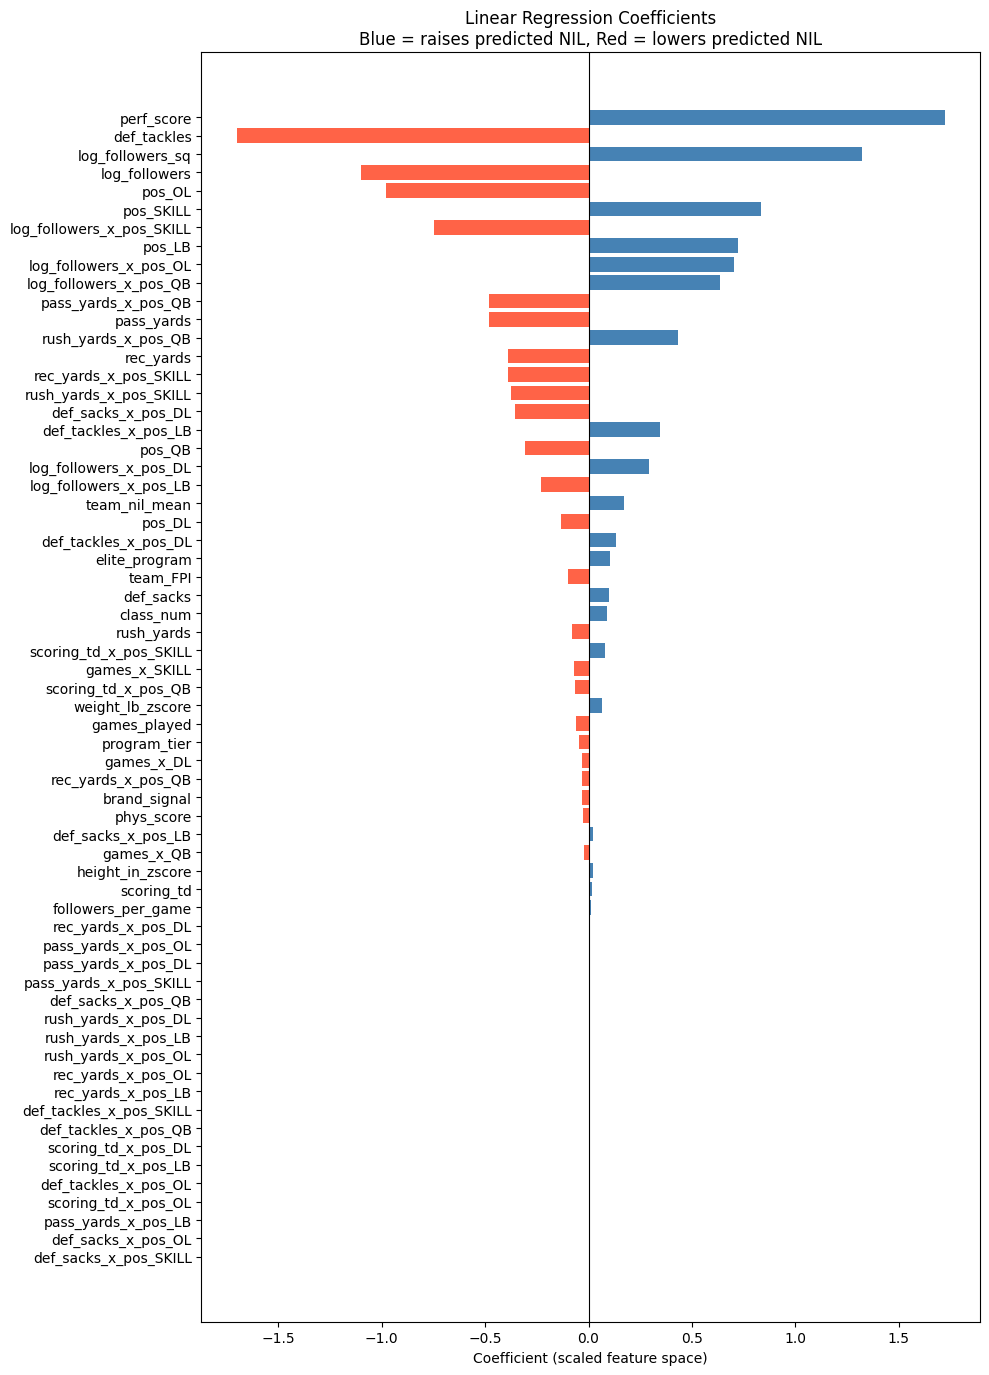

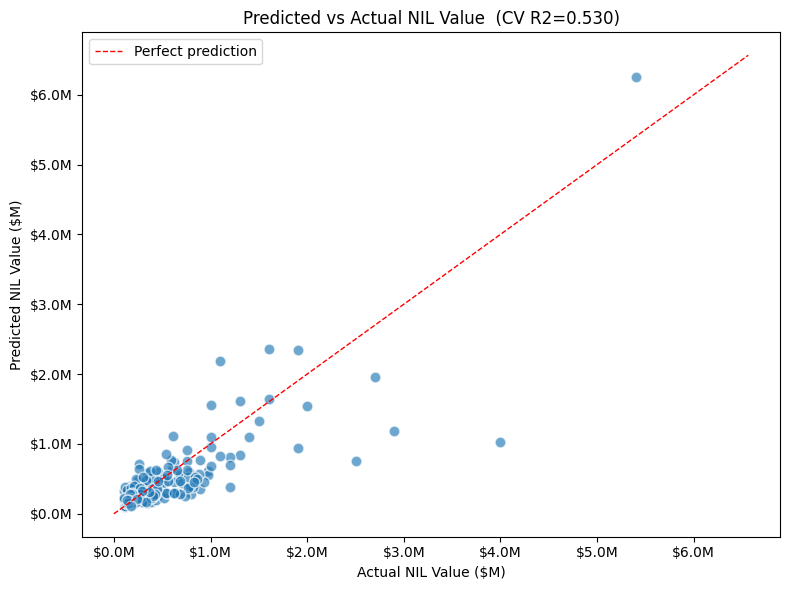

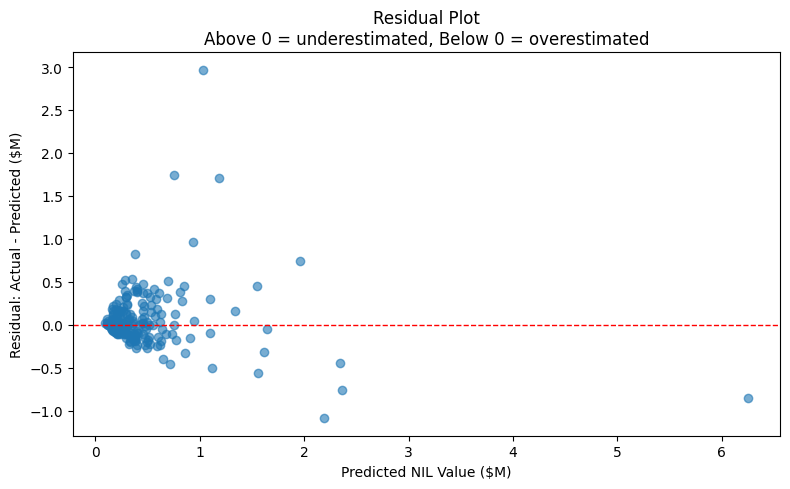

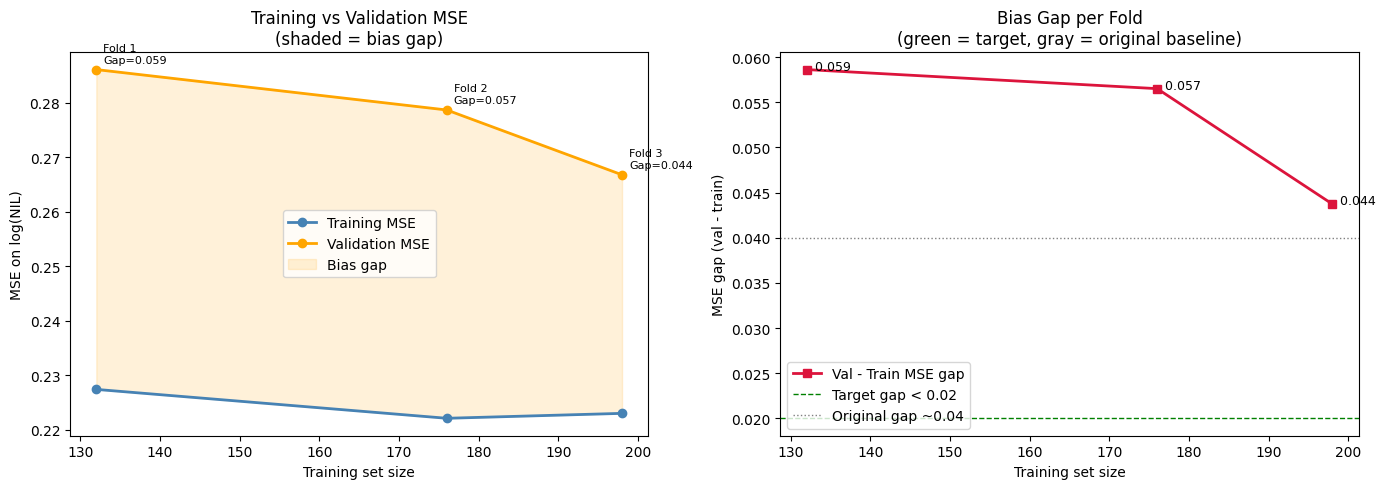

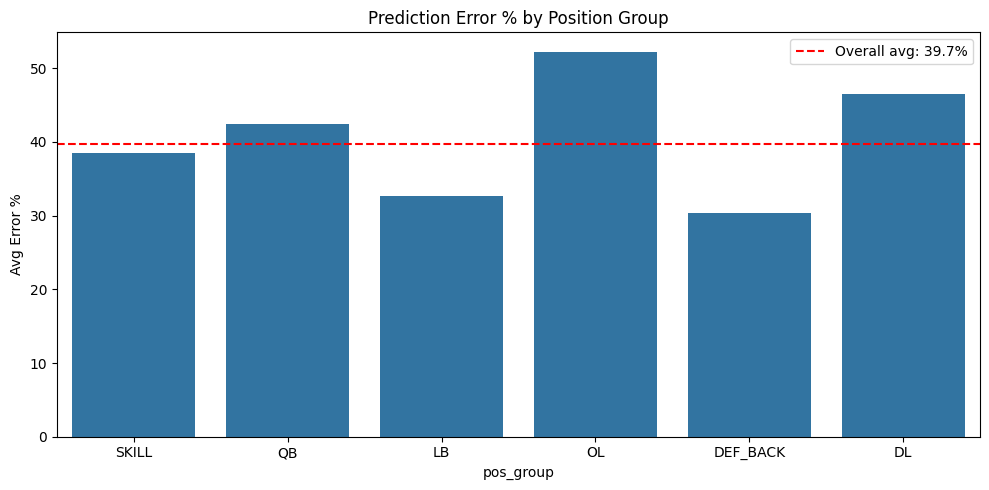


Held-out rolling validation predictions:


,name,position,pos_group,actual_nil,predicted_nil,error_pct
0,DeShawn Gaddie Jr.,CB,DEF_BACK,140000,140058,0.0
1,Vernell Brown III,WR,SKILL,322000,322372,0.1
2,Hero Kanu,DL,DL,655000,653274,0.3
3,Joseph Jonah-Ajonye,DL,DL,232000,233172,0.5
4,Adonyss Currie,CB,DEF_BACK,149000,149873,0.6
...,...,...,...,...,...,...
84,Josiah Thompson,OT,OL,182000,430319,136.4
85,Peyton Williams,S,DEF_BACK,218000,529450,142.9
86,Raleek Brown,RB,SKILL,535000,1442462,169.6
87,Dakereon Joyner,RB,SKILL,109000,300578,175.8


In [ ]:
y_final_log = final_model.predict(X_scaled)
y_final     = np.exp(y_final_log)
y_actual    = np.exp(y.values)

mae_final = mean_absolute_error(y_actual, y_final)
mse_final = mean_squared_error(y.values, y_final_log)
r2_final  = r2_score(y.values, y_final_log)

print(f'In-sample R2 (log scale):         {r2_final:.3f}')
print(f'Rolling CV R2 (held-out):         {val_r2_overall:.3f}')
print(f'5-Fold CV R2 (retrain best seed): {best_r2:.4f}')
print(f'In-sample MSE (log scale):        {mse_final:.4f}')
print(f'Rolling CV MSE (held-out):        {val_mse_overall:.4f}')
print(f'Avg MSE gap across folds:         {fold_metrics["mse_gap"].mean():.4f}  (original was ~0.040)')
print(f'MAE ($):                          ${mae_final:,.0f}')

coef_df = pd.DataFrame({
    'feature': all_features,
    'coefficient': final_model.coef_
}).sort_values('coefficient', key=np.abs, ascending=True)

plt.figure(figsize=(10, max(8, len(coef_df) * 0.22)))
colors = ['tomato' if c < 0 else 'steelblue' for c in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Linear Regression Coefficients\nBlue = raises predicted NIL, Red = lowers predicted NIL')
plt.xlabel('Coefficient (scaled feature space)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(y_actual/1e6, y_final/1e6, alpha=0.65, edgecolors='white', s=60)
lim = max(y_actual.max(), y_final.max()) / 1e6 * 1.05
plt.plot([0, lim], [0, lim], 'r--', linewidth=1, label='Perfect prediction')
plt.xlabel('Actual NIL Value ($M)')
plt.ylabel('Predicted NIL Value ($M)')
plt.title(f'Predicted vs Actual NIL Value  (CV R2={best_r2:.3f})')
plt.legend()
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
plt.tight_layout()
plt.show()

residuals_plot = y_actual - y_final
plt.figure(figsize=(8, 5))
plt.scatter(y_final/1e6, residuals_plot/1e6, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Predicted NIL Value ($M)')
plt.ylabel('Residual: Actual - Predicted ($M)')
plt.title('Residual Plot\nAbove 0 = underestimated, Below 0 = overestimated')
plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(fold_metrics['train_size'], fold_metrics['train_mse'], marker='o', linewidth=2, label='Training MSE', color='steelblue')
ax1.plot(fold_metrics['train_size'], fold_metrics['val_mse'],   marker='o', linewidth=2, label='Validation MSE', color='orange')
ax1.fill_between(fold_metrics['train_size'], fold_metrics['train_mse'], fold_metrics['val_mse'],
                 alpha=0.15, color='orange', label='Bias gap')
for _, row in fold_metrics.iterrows():
    ax1.annotate(f"Fold {int(row['fold'])}\nGap={row['mse_gap']:.3f}",
                 (row['train_size'], row['val_mse']),
                 textcoords='offset points', xytext=(5, 5), fontsize=8)
ax1.set_xlabel('Training set size')
ax1.set_ylabel('MSE on log(NIL)')
ax1.set_title('Training vs Validation MSE\n(shaded = bias gap)')
ax1.legend()

ax2.plot(fold_metrics['train_size'], fold_metrics['mse_gap'], marker='s', linewidth=2,
         color='crimson', label='Val - Train MSE gap')
ax2.axhline(0.02, color='green', linestyle='--', linewidth=1, label='Target gap < 0.02')
ax2.axhline(0.04, color='gray', linestyle=':', linewidth=1, label='Original gap ~0.04')
for _, row in fold_metrics.iterrows():
    ax2.annotate(f"  {row['mse_gap']:.3f}", (row['train_size'], row['mse_gap']), fontsize=9)
ax2.set_xlabel('Training set size')
ax2.set_ylabel('MSE gap (val - train)')
ax2.set_title('Bias Gap per Fold\n(green = target, gray = original baseline)')
ax2.legend()

plt.tight_layout()
plt.show()

results = df_labeled[['name','position','pos_group','nil_value']].copy()
results['predicted'] = y_final.round(0).astype(int)
results['error_pct'] = ((results['predicted'] - results['nil_value']).abs()
                        / results['nil_value'] * 100).round(1)

plt.figure(figsize=(10, 5))
sns.barplot(data=results, x='pos_group', y='error_pct', errorbar=('ci', False))
plt.axhline(results['error_pct'].mean(), color='red', linestyle='--',
            label=f"Overall avg: {results['error_pct'].mean():.1f}%")
plt.title('Prediction Error % by Position Group')
plt.ylabel('Avg Error %')
plt.legend()
plt.tight_layout()
plt.show()

validated_mask = np.zeros(n, dtype=bool)
validated_mask[val_slice] = True

val_df = pd.DataFrame({
    'name': names_shuf[validated_mask],
    'actual_nil': np.exp(all_val_actual[validated_mask]).round(0).astype(int),
    'predicted_nil': np.exp(all_val_preds[validated_mask]).round(0).astype(int)
})
name_to_meta = df_labeled.set_index('name')[['position','pos_group']]
val_df = val_df.join(name_to_meta, on='name')
val_df['error_pct'] = ((val_df['predicted_nil'] - val_df['actual_nil']).abs()
                       / val_df['actual_nil'] * 100).round(1)
val_df = val_df[['name','position','pos_group','actual_nil','predicted_nil','error_pct']]
val_df = val_df.sort_values('error_pct').reset_index(drop=True)

print('\nHeld-out rolling validation predictions:')
val_df

In [21]:
results_sorted = results.sort_values('error_pct').reset_index(drop=True)
results_sorted.columns = ['Name','Position','Pos Group','Actual NIL','Predicted NIL','Error %']
print('All labeled players -- predicted vs actual (sorted by accuracy):')
results_sorted

All labeled players -- predicted vs actual (sorted by accuracy):


,Name,Position,Pos Group,Actual NIL,Predicted NIL,Error %
0,Jackson Arnold,QB,QB,752000.0,752900,0.1
1,Suntarine Perkins,EDGE,DL,519000.0,516817,0.4
2,Hollywood Smothers,RB,SKILL,550000.0,553353,0.6
3,Adonyss Currie,CB,DEF_BACK,149000.0,150385,0.9
4,Nikhai Hill-Green,LB,LB,151000.0,149652,0.9
...,...,...,...,...,...,...
216,Juan Gaston,OL,OL,166000.0,401841,142.1
217,John Campbell,OT,OL,255000.0,648055,154.1
218,Amare Campbell,LB,LB,257000.0,716843,178.9
219,Dominick McKinley,DT,DL,106000.0,323813,205.5


In [22]:
df_unlabeled['predicted_nil'] = np.exp(final_model.predict(X_pred_scaled)).round(0).astype(int)

gap_predictions = df_unlabeled[['name','team','position','pos_group','predicted_nil']]\
    .sort_values('predicted_nil', ascending=False).reset_index(drop=True)

print(f'Predicted NIL values for {len(gap_predictions)} players with no existing NIL:')
gap_predictions

Predicted NIL values for 99 players with no existing NIL:


,name,team,position,pos_group,predicted_nil
0,Jordan Matthews,Vanderbilt Commodores,CB,DEF_BACK,5727810
1,Air Noland,South Carolina Gamecocks,QB,QB,770257
2,CJ Heard,Vanderbilt Commodores,S,DEF_BACK,557414
3,Princewill Umanmielen,Ole Miss Rebels,LB,LB,556414
4,Davhon Keys,LSU Tigers,LB,LB,543795
...,...,...,...,...,...
94,Jaylen Mahoney,Vanderbilt Commodores,CB,DEF_BACK,97447
95,Carson Lawrence,Vanderbilt Commodores,S,DEF_BACK,97318
96,BJ Anderson,Vanderbilt Commodores,CB,DEF_BACK,83519
97,Blake Shapen,Mississippi State Bulldogs,QB,QB,33693


In [23]:
os.makedirs('model_artifacts', exist_ok=True)

joblib.dump(final_model, 'model_artifacts/nil_model.pkl')
joblib.dump(scaler,      'model_artifacts/scaler.pkl')

meta = {
    'all_features':         all_features,
    'pos_cols':             pos_cols,
    'perf_cols':            perf_cols,
    'follower_pos_features': follower_pos_features,
    'pos_map':              pos_map,
    'class_map':            class_map,
    'class_season_weight':  class_season_weight,
    'PERF_WEIGHTS':         PERF_WEIGHTS,
    'PHYSICAL_WEIGHTS':     PHYSICAL_WEIGHTS,
    'stat_pairs':           stat_pairs,
    'best_cv_r2':           float(best_r2),
    'perf_stats_mean':      perf_stats['mean'].to_dict(),
    'perf_stats_std':       perf_stats['std'].to_dict(),
    'team_nil_mean':        team_nil_mean.to_dict(),
    'global_nil_mean':      float(global_nil_mean),
    'phys_stats': {
        col: {
            'mean': phys_stats[(col,'mean')].to_dict(),
            'std':  phys_stats[(col,'std')].to_dict(),
        }
        for col in ['height_in','weight_lb']
    },
}
with open('model_artifacts/meta.json','w') as f:
    json.dump(meta, f, indent=2)

print('Saved: model_artifacts/nil_model.pkl')
print('Saved: model_artifacts/scaler.pkl')
print('Saved: model_artifacts/meta.json')
print(f'CV R2 achieved: {best_r2:.4f}')

Saved: model_artifacts/nil_model.pkl
Saved: model_artifacts/scaler.pkl
Saved: model_artifacts/meta.json
CV R2 achieved: 0.5304


In [24]:
new_player = {
    'position':           'WR',
    'class':              'JR',
    'height_in':          73,
    'weight_lb':          195,
    'games_played':       30,
    'follower_count':     125000,
    'team_FPI':           15.0,
    'team_RK':            18,
    'program_tier':       3,
    'team':               'Alabama Crimson Tide',   
    'season_pass_yards':  0,   'career_pass_yards':  0,
    'season_rec_yards':   850, 'career_rec_yards':   1400,
    'season_rush_yards':  30,  'career_rush_yards':  60,
    'season_scoring_td':  7,   'career_scoring_td':  14,
    'season_def_tackles': 0,   'career_def_tackles': 0,
    'season_def_sacks':   0.0, 'career_def_sacks':   0.0,
}

def predict_new_player(player_dict):
    row = pd.DataFrame([player_dict])
    row['pos_group'] = pos_map.get(row['position'].values[0], 'OL')
    row['class_num'] = class_map.get(row['class'].values[0], 2)

    pg = row['pos_group'].values[0]
    w  = class_season_weight.get(row['class'].values[0], 0.4)
    for new_col, s_col, c_col in stat_pairs:
        row[new_col] = w * row[s_col].values[0] + (1-w) * row[c_col].values[0]

    mask_qb    = pg == 'QB';  mask_skill = pg == 'SKILL'
    mask_ol    = pg == 'OL';  mask_def   = pg in ['DEF_BACK','LB','DL']
    if not mask_qb:                    row['pass_yards']  = 0
    if not mask_skill and not mask_qb: row['rec_yards']   = 0
    if mask_ol or mask_def:            row['rush_yards']  = 0
    if mask_ol or mask_def:            row['scoring_td']  = 0
    if not mask_def:                   row['def_tackles'] = 0
    if not mask_def:                   row['def_sacks']   = 0

    for col in ['height_in','weight_lb']:
        grp = df_labeled[df_labeled['pos_group'] == pg]
        mu, sig = grp[col].mean(), grp[col].std()
        row[f'{col}_zscore'] = (row[col].values[0] - mu) / sig if sig > 0 else 0

    row['perf_score_raw'] = compute_perf_score(row.iloc[0])
    if pg in perf_stats.index and perf_stats.loc[pg,'std'] > 0:
        row['perf_score'] = (row['perf_score_raw'].values[0] - perf_stats.loc[pg,'mean']) / perf_stats.loc[pg,'std']
    else:
        row['perf_score'] = 0.0

    row['phys_score'] = compute_phys_score(row.iloc[0])

    fc = float(str(player_dict['follower_count']).replace(',',''))
    gp = max(float(player_dict.get('games_played', 1) or 1), 1)
    row['log_followers']      = np.log1p(fc)
    row['log_followers_sq']   = row['log_followers'].values[0] ** 2
    row['followers_per_game'] = np.log1p(fc / gp)
    row['elite_program']      = float((player_dict.get('program_tier', 5) <= 3) and
                                      (player_dict.get('team_FPI', 0) >= 10))
    row['brand_signal']       = row['log_followers'].values[0] * row['elite_program'].values[0] * (max(row['perf_score'].values[0], 0) + 1)
    row['games_x_QB']         = gp * float(pg == 'QB')
    row['games_x_SKILL']      = gp * float(pg == 'SKILL')
    row['games_x_DL']         = gp * float(pg == 'DL')
    row['team_nil_mean']      = team_nil_mean.get(player_dict.get('team',''), global_nil_mean)

    for pc in pos_cols:
        row[pc] = 1.0 if pc == f'pos_{pg}' else 0.0

    for pc in pos_cols:
        row[f'log_followers_x_{pc}'] = row['log_followers'].values[0] * row[pc].values[0]

    for stat in perf_cols:
        for pc in pos_cols:
            row[f'{stat}_x_{pc}'] = row[stat].values[0] * row[pc].values[0]

    X_new = row[all_features].fillna(0)
    return int(np.exp(final_model.predict(scaler.transform(X_new))[0]))

print(f'Predicted NIL Value: ${predict_new_player(new_player):,.0f}')

Predicted NIL Value: $910,388
